In [1]:
# ===============================
# 📦 Importing Libraries
# ===============================

# 🚀 Data Manipulation and Analysis
import pandas as pd  # DataFrame operations
import numpy as np   # Numerical computations

# 📊 Data Visualization
import matplotlib.pyplot as plt  # Plotting static graphs
import seaborn as sns            # Advanced data visualization
import plotly.express as px      # Interactive visualizations
import plotly.graph_objects as go  # Custom interactive plots

In [2]:
# 🛠 Utility Tools
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner outputs

In [3]:
data= pd.read_csv("/Users/ne20641962/Desktop/Capstone_Project/cyberfeddefender_dataset 2.csv")
print(data.head())


             Timestamp    Source_IP Destination_IP Protocol  Packet_Length  \
0  2024-10-23 12:00:00  192.168.0.1    192.168.0.1     ICMP           1155   
1  2024-10-23 12:00:01  192.168.0.7     172.16.0.5     ICMP           1776   
2  2024-10-23 12:00:02  192.168.0.7       10.0.0.3      UDP            627   
3  2024-10-23 12:00:03  192.168.0.7       10.0.0.3      UDP           1754   
4  2024-10-23 12:00:04  192.168.0.1       10.0.0.4      UDP           1326   

   Duration  Source_Port  Destination_Port  Bytes_Sent  Bytes_Received  ...  \
0      4.01           53                53         675             877  ...   
1      3.75           22                22         297            1062  ...   
2      4.24           80              8080         122             723  ...   
3      3.09          443               443        1626            1703  ...   
4      2.52           80               443        1851             771  ...   

  Avg_Packet_Size  Total_Fwd_Packets  Total_Bwd_Packets 

In [4]:
# ===============================
# 🧐 Exploring the Dataset
# ===============================

# Display basic information about the dataset
print("\n🔍 Dataset Info:")
print(data.info())


🔍 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           1430 non-null   object 
 1   Source_IP           1430 non-null   object 
 2   Destination_IP      1430 non-null   object 
 3   Protocol            1430 non-null   object 
 4   Packet_Length       1430 non-null   int64  
 5   Duration            1430 non-null   float64
 6   Source_Port         1430 non-null   int64  
 7   Destination_Port    1430 non-null   int64  
 8   Bytes_Sent          1430 non-null   int64  
 9   Bytes_Received      1430 non-null   int64  
 10  Flags               1430 non-null   object 
 11  Flow_Packets/s      1430 non-null   float64
 12  Flow_Bytes/s        1430 non-null   float64
 13  Avg_Packet_Size     1430 non-null   int64  
 14  Total_Fwd_Packets   1430 non-null   int64  
 15  Total_Bwd_Packets   1430 non-null   in

In [5]:
# Display the first few rows for a quick preview
print("\n📋 First 5 Rows:")
print(data.head())


📋 First 5 Rows:
             Timestamp    Source_IP Destination_IP Protocol  Packet_Length  \
0  2024-10-23 12:00:00  192.168.0.1    192.168.0.1     ICMP           1155   
1  2024-10-23 12:00:01  192.168.0.7     172.16.0.5     ICMP           1776   
2  2024-10-23 12:00:02  192.168.0.7       10.0.0.3      UDP            627   
3  2024-10-23 12:00:03  192.168.0.7       10.0.0.3      UDP           1754   
4  2024-10-23 12:00:04  192.168.0.1       10.0.0.4      UDP           1326   

   Duration  Source_Port  Destination_Port  Bytes_Sent  Bytes_Received  ...  \
0      4.01           53                53         675             877  ...   
1      3.75           22                22         297            1062  ...   
2      4.24           80              8080         122             723  ...   
3      3.09          443               443        1626            1703  ...   
4      2.52           80               443        1851             771  ...   

  Avg_Packet_Size  Total_Fwd_Packets  T

In [6]:
# Display basic statistics for numerical columns
print("\n📊 Dataset Statistics:")
print(data.describe(include='all'))


📊 Dataset Statistics:
                  Timestamp    Source_IP Destination_IP Protocol  \
count                  1430         1430           1430     1430   
unique                 1430            9              6        3   
top     2024-10-23 12:00:00  192.168.0.1       10.0.0.3      UDP   
freq                      1          291            340      502   
mean                    NaN          NaN            NaN      NaN   
std                     NaN          NaN            NaN      NaN   
min                     NaN          NaN            NaN      NaN   
25%                     NaN          NaN            NaN      NaN   
50%                     NaN          NaN            NaN      NaN   
75%                     NaN          NaN            NaN      NaN   
max                     NaN          NaN            NaN      NaN   

        Packet_Length     Duration  Source_Port  Destination_Port  \
count     1430.000000  1430.000000  1430.000000       1430.000000   
unique            NaN 

In [7]:
# ===============================
# 🔍 Checking for Missing Data
# ===============================

# Display the count of missing values for each column
missing_data = data.isnull().sum()
print("\n🔍 Missing Data Summary:")
print(missing_data[missing_data > 0])  # Display only columns with missing values


🔍 Missing Data Summary:
Series([], dtype: int64)


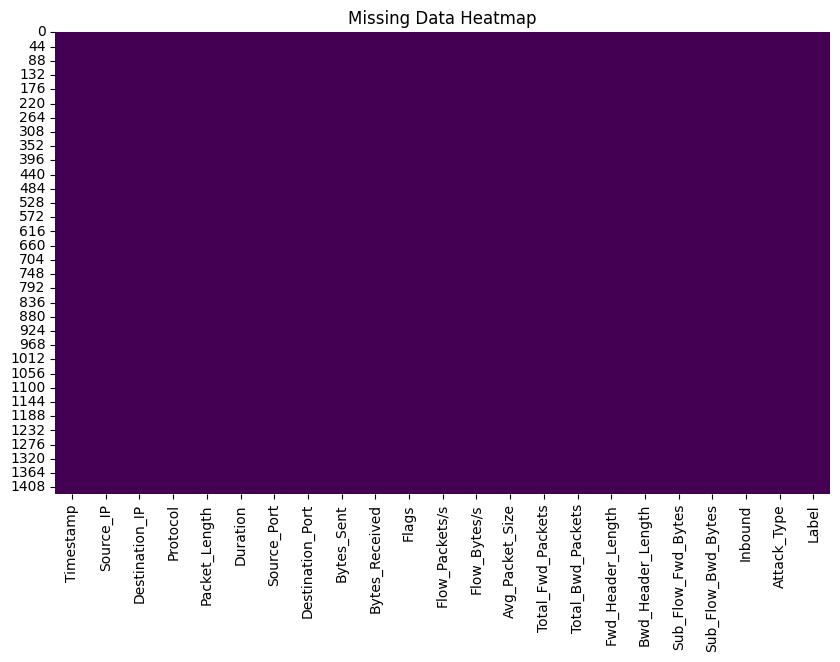

In [8]:
# Visualizing missing data (optional for better insight)
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

In [9]:
# ===============================
# ⚖️ Homogeneity Testing
# ===============================

# Importing necessary libraries for statistical tests
from scipy.stats import levene

In [10]:
# Selecting numerical columns for homogeneity testing
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

In [11]:
# Performing Levene's test for homogeneity
print("\n⚖️ Homogeneity Test Results:")
for column in numerical_columns:
    stat, p_value = levene(data[column].dropna(), data[numerical_columns[0]].dropna())
    print(f"Column: {column} | Statistic: {stat:.3f} | P-value: {p_value:.3f}")

    if p_value < 0.05:
        print(f"❌ {column} does not have homogeneous variance.")
    else:
        print(f"✅ {column} passes the homogeneity test.")


⚖️ Homogeneity Test Results:
Column: Packet_Length | Statistic: 0.000 | P-value: 1.000
✅ Packet_Length passes the homogeneity test.
Column: Duration | Statistic: 4321.020 | P-value: 0.000
❌ Duration does not have homogeneous variance.
Column: Source_Port | Statistic: 187.979 | P-value: 0.000
❌ Source_Port does not have homogeneous variance.
Column: Destination_Port | Statistic: 229.082 | P-value: 0.000
❌ Destination_Port does not have homogeneous variance.
Column: Bytes_Sent | Statistic: 0.179 | P-value: 0.673
✅ Bytes_Sent passes the homogeneity test.
Column: Bytes_Received | Statistic: 0.004 | P-value: 0.950
✅ Bytes_Received passes the homogeneity test.
Column: Flow_Packets/s | Statistic: 4209.474 | P-value: 0.000
❌ Flow_Packets/s does not have homogeneous variance.
Column: Flow_Bytes/s | Statistic: 0.682 | P-value: 0.409
✅ Flow_Bytes/s passes the homogeneity test.
Column: Avg_Packet_Size | Statistic: 345.593 | P-value: 0.000
❌ Avg_Packet_Size does not have homogeneous variance.
Colu

In [12]:
# ===============================
# 📌 Next Step
# ===============================
# Proceed with data normalization or feature engineering based on test results.
print("\n✅ Missing data handling and homogeneity testing completed!")


✅ Missing data handling and homogeneity testing completed!


In [13]:
# ===============================
# ⚖️ Normalizing Features
# ===============================

# Columns with non-homogeneous variance
columns_to_normalize = [
'Duration','Source_Port','Destination_Port',
'Flow_Packets/s','Avg_Packet_Size',
'Total_Fwd_Packets','Total_Bwd_Packets',
'Fwd_Header_Length','Inbound'
]

In [14]:

# Applying log transformation to stabilize variance
for col in columns_to_normalize:
    data[col] = np.log1p(data[col])  # log1p handles log(0) safely

In [16]:

# ===============================
# 🔧 Scaling Features
# ===============================

# Importing MinMaxScaler for scaling
from sklearn.preprocessing import MinMaxScaler

In [17]:
# Initialize scaler
scaler = MinMaxScaler()

In [18]:
# Selecting numerical columns for scaling
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns


In [19]:
# Scaling the numerical columns
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

In [21]:
# ===============================
# ✅ Verification
# ===============================

# Display the first few rows of the normalized and scaled dataset
print("\n📋 Transformed Dataset (First 5 Rows):")
print(data.head())


📋 Transformed Dataset (First 5 Rows):
             Timestamp    Source_IP Destination_IP Protocol  Packet_Length  \
0  2024-10-23 12:00:00  192.168.0.1    192.168.0.1     ICMP       0.550454   
1  2024-10-23 12:00:01  192.168.0.7     172.16.0.5     ICMP       0.863774   
2  2024-10-23 12:00:02  192.168.0.7       10.0.0.3      UDP       0.284057   
3  2024-10-23 12:00:03  192.168.0.7       10.0.0.3      UDP       0.852674   
4  2024-10-23 12:00:04  192.168.0.1       10.0.0.4      UDP       0.636731   

   Duration  Source_Port  Destination_Port  Bytes_Sent  Bytes_Received  ...  \
0  0.893705     0.145603          0.145603    0.308081        0.410606  ...   
1  0.862292     0.000000          0.000000    0.117172        0.504040  ...   
2  0.920164     0.214774          1.000000    0.028788        0.332828  ...   
3  0.774108     0.505023          0.505023    0.788384        0.827778  ...   
4  0.685638     0.214774          0.505023    0.902020        0.357071  ...   

  Avg_Packet_Size

In [22]:
# Check if the scaling was successful
print("\n📊 Summary Statistics After Scaling:")
print(data[numerical_columns].describe())


📊 Summary Statistics After Scaling:
       Packet_Length     Duration  Source_Port  Destination_Port   Bytes_Sent  \
count    1430.000000  1430.000000  1430.000000       1430.000000  1430.000000   
mean        0.504803     0.641130     0.369891          0.370080     0.480253   
std         0.288818     0.269931     0.349908          0.365590     0.287576   
min         0.000000     0.000000     0.000000          0.000000     0.000000   
25%         0.251261     0.449970     0.145603          0.145603     0.221212   
50%         0.505550     0.699703     0.214774          0.214774     0.481818   
75%         0.744198     0.873356     0.505023          0.505023     0.723232   
max         1.000000     1.000000     1.000000          1.000000     1.000000   

       Bytes_Received  Flow_Packets/s  Flow_Bytes/s  Avg_Packet_Size  \
count     1430.000000     1430.000000   1430.000000      1430.000000   
mean         0.495723        0.598513      0.498249         0.560527   
std          0.28

In [23]:
# ===============================
# 📌 Next Step
# ===============================
# Proceed to feature engineering or model training.
print("\n✅ Features normalized and scaled successfully!")


✅ Features normalized and scaled successfully!


In [25]:
# ===============================
# 🔍 Dataset Overview
# ===============================

# Summary statistics for all columns
print("\n📊 Complete Summary Statistics:")
print(data.describe(include='all'))


📊 Complete Summary Statistics:
                  Timestamp    Source_IP Destination_IP Protocol  \
count                  1430         1430           1430     1430   
unique                 1430            9              6        3   
top     2024-10-23 12:00:00  192.168.0.1       10.0.0.3      UDP   
freq                      1          291            340      502   
mean                    NaN          NaN            NaN      NaN   
std                     NaN          NaN            NaN      NaN   
min                     NaN          NaN            NaN      NaN   
25%                     NaN          NaN            NaN      NaN   
50%                     NaN          NaN            NaN      NaN   
75%                     NaN          NaN            NaN      NaN   
max                     NaN          NaN            NaN      NaN   

        Packet_Length     Duration  Source_Port  Destination_Port  \
count     1430.000000  1430.000000  1430.000000       1430.000000   
unique       

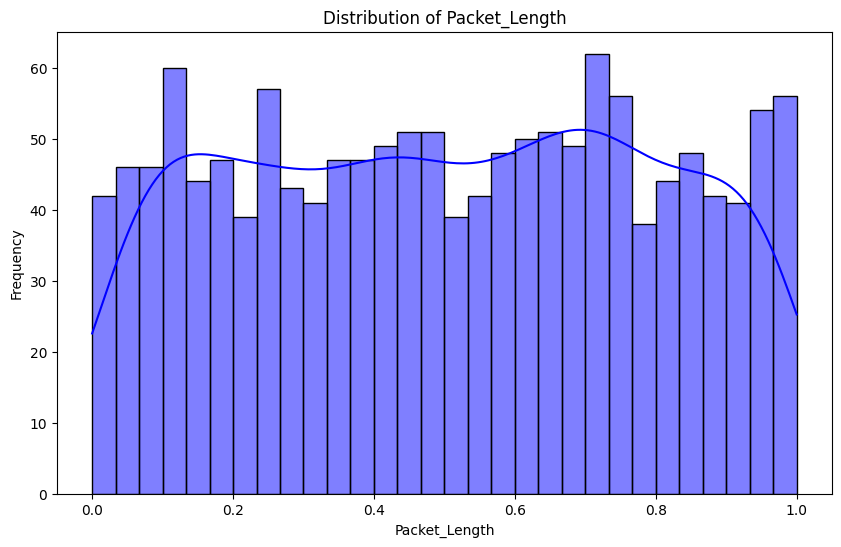

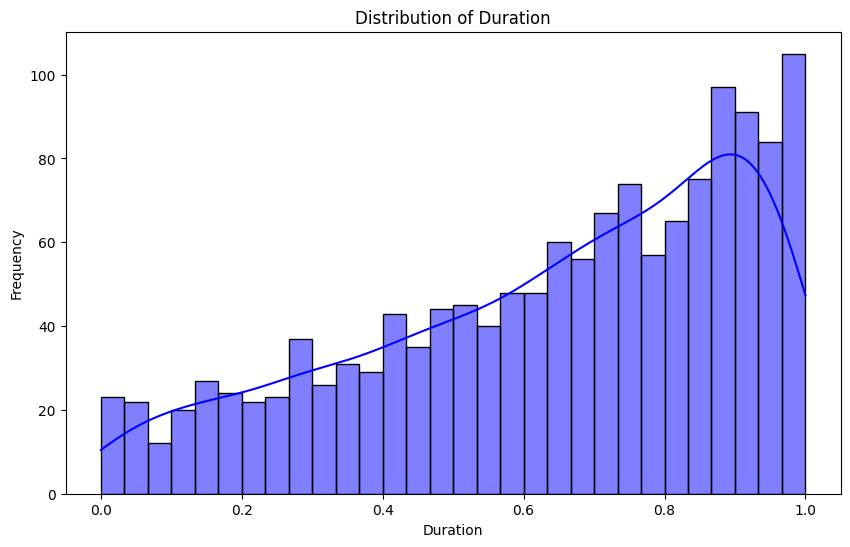

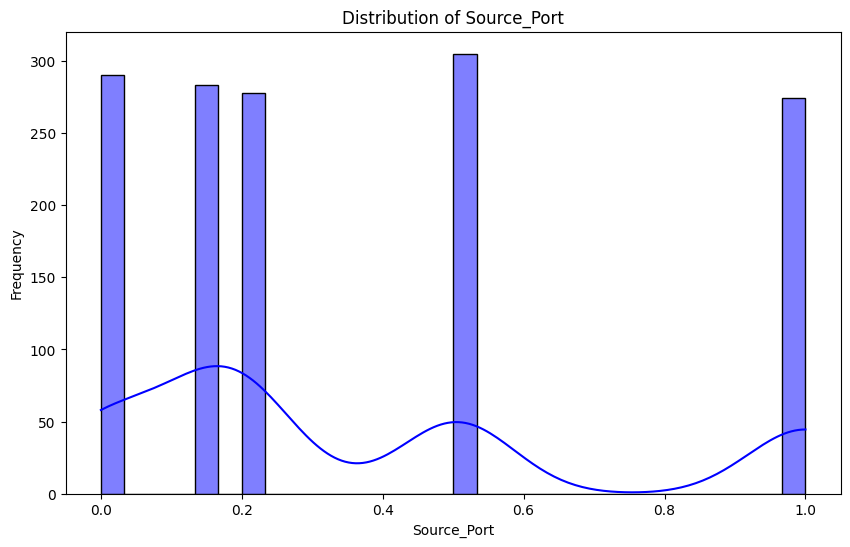

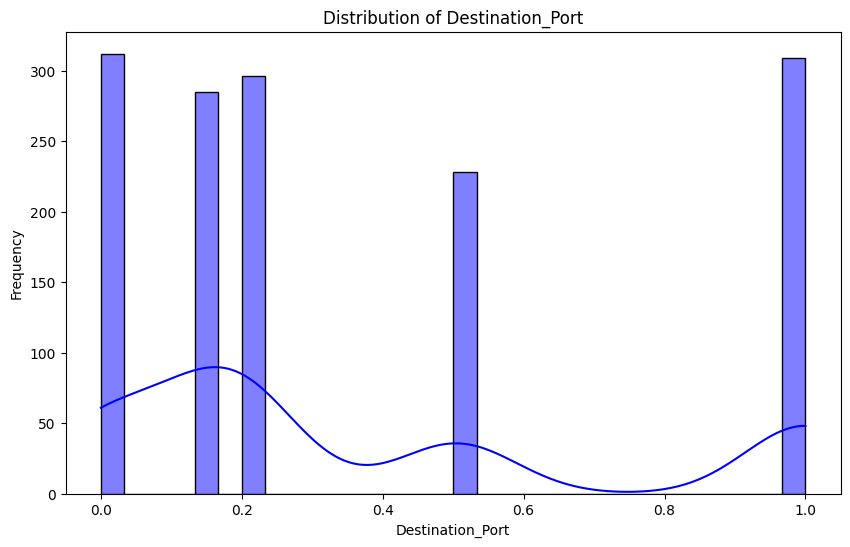

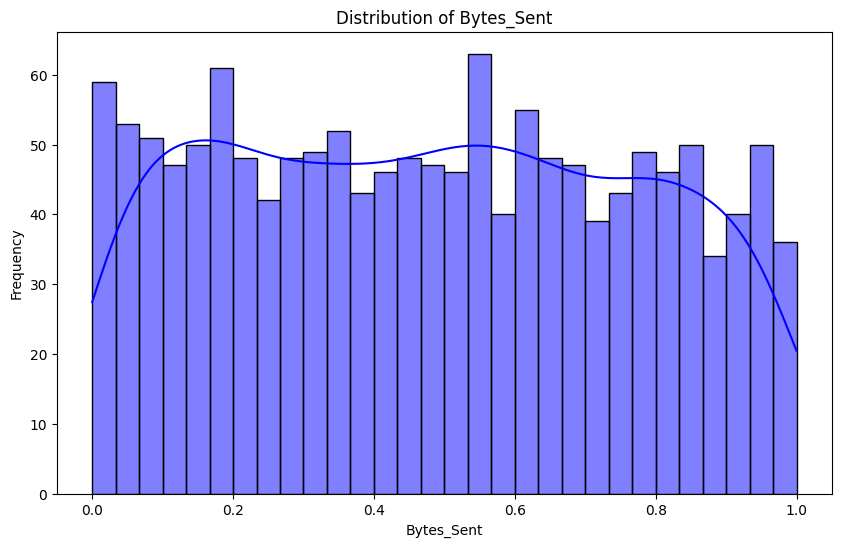

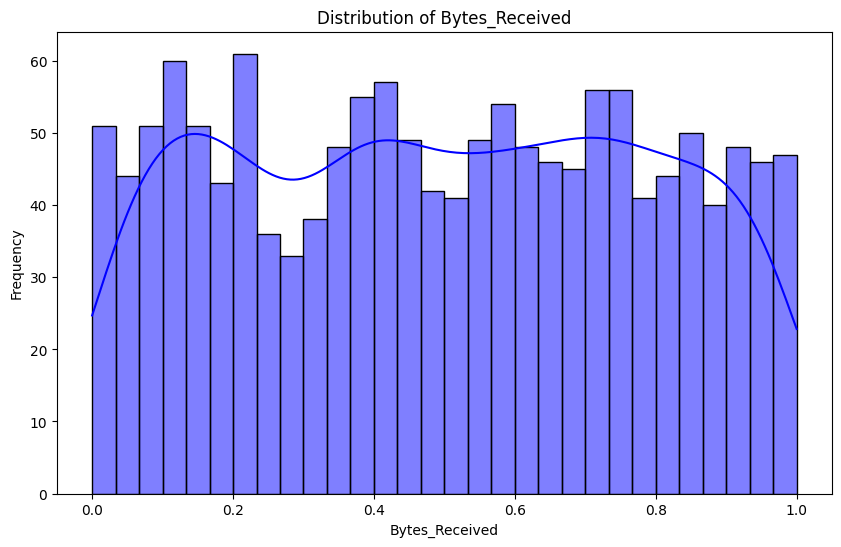

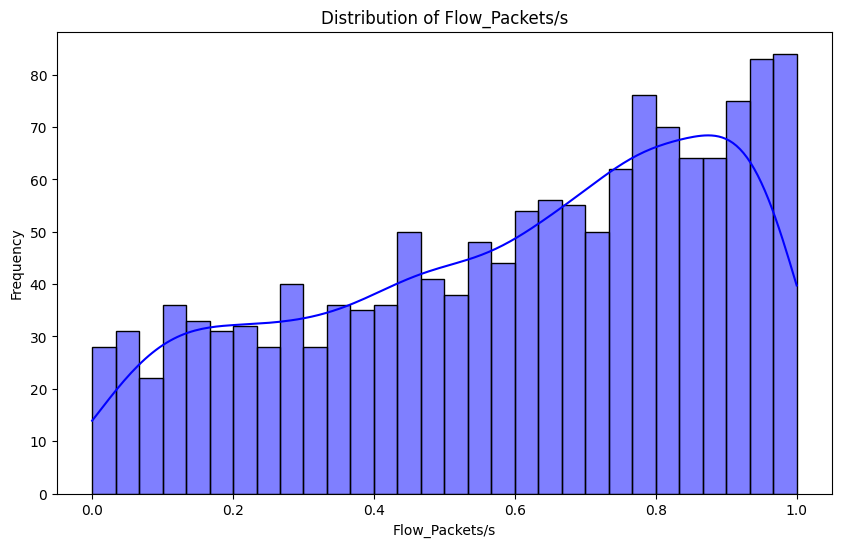

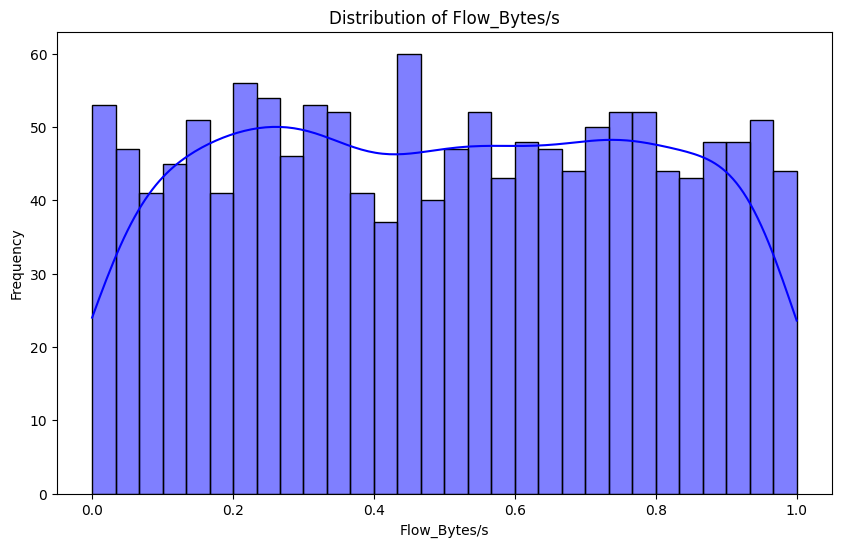

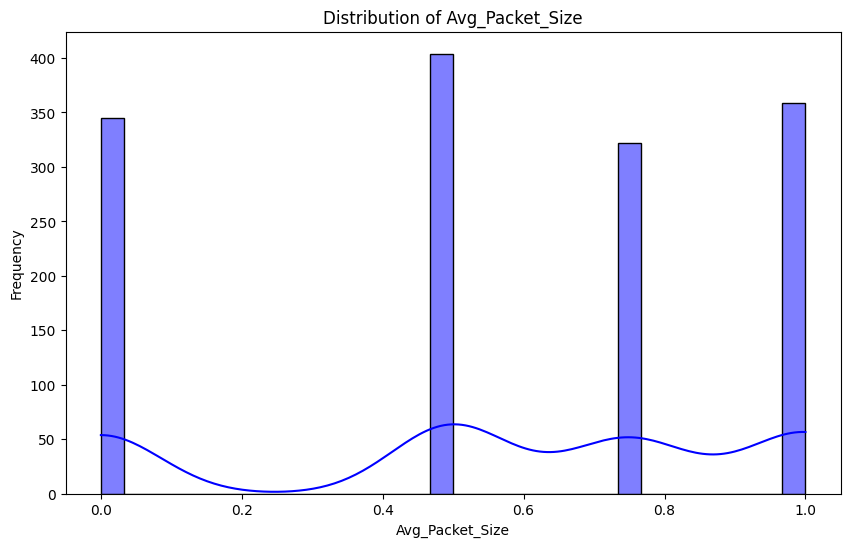

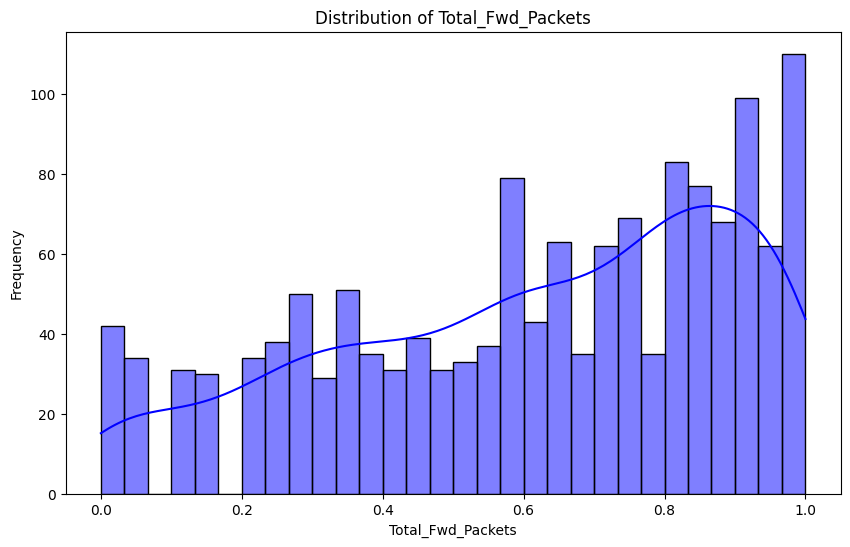

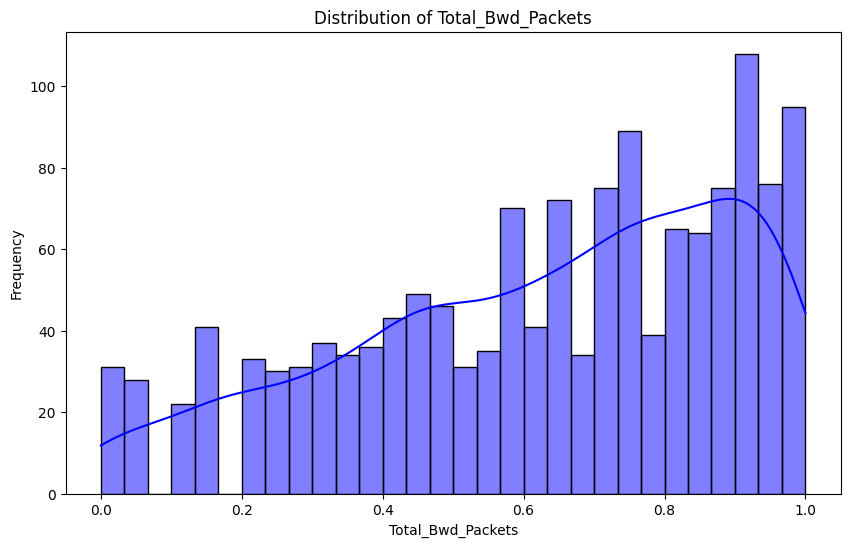

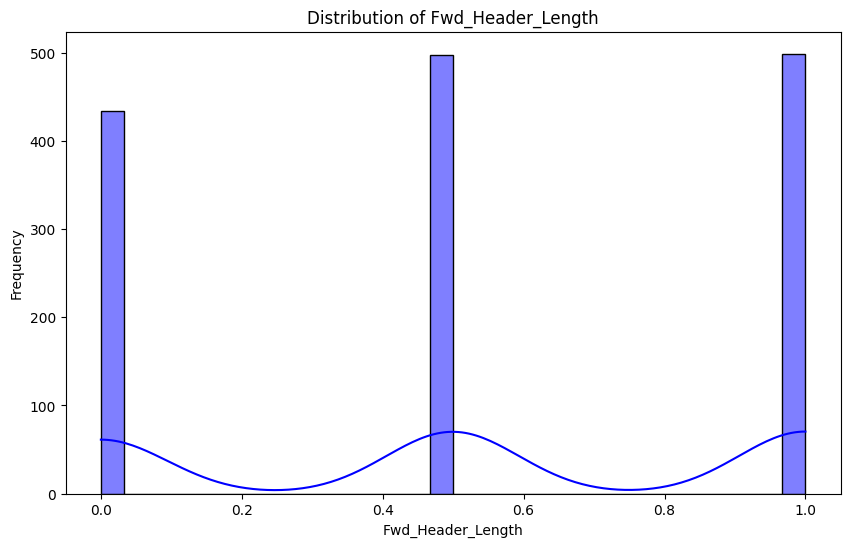

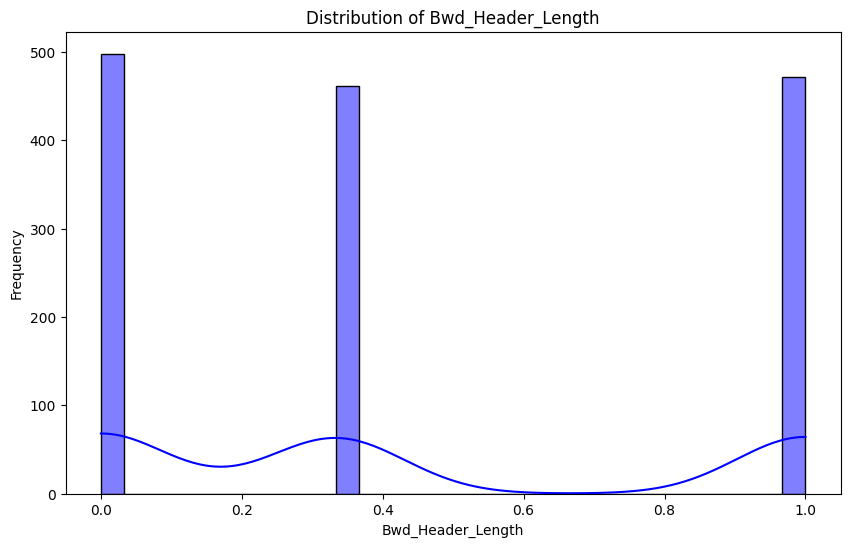

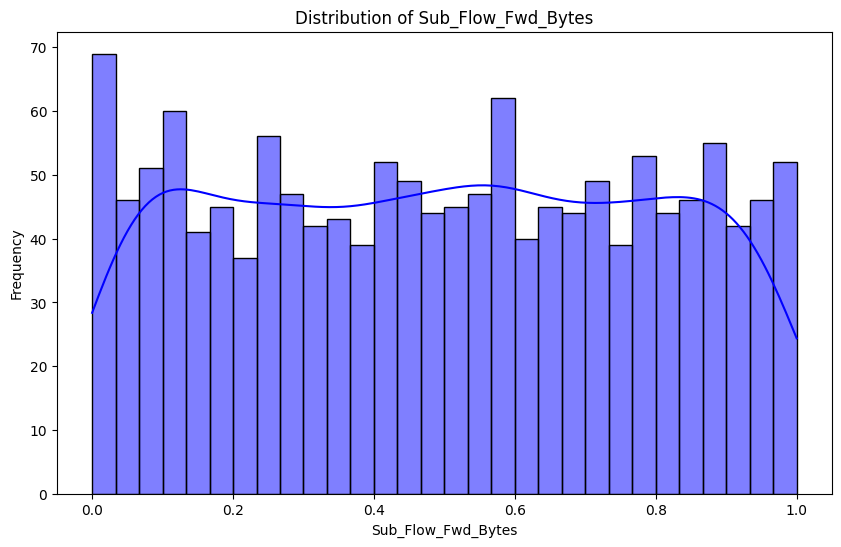

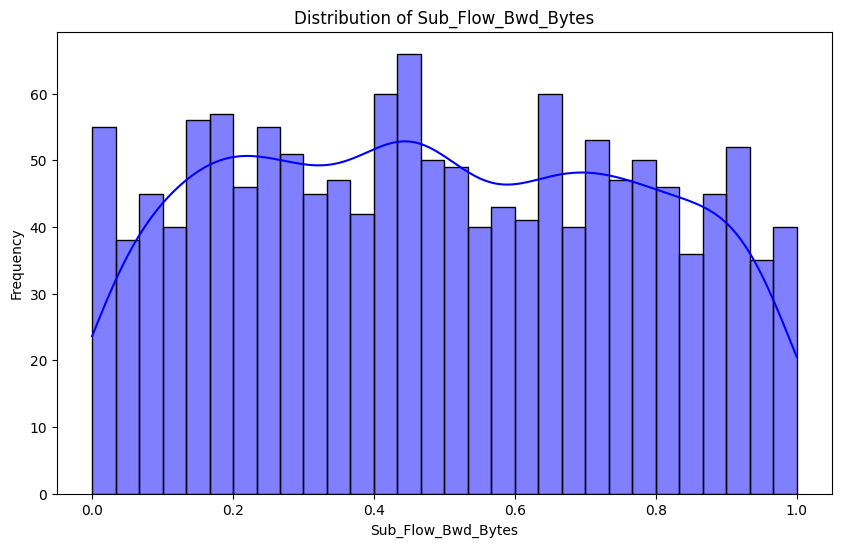

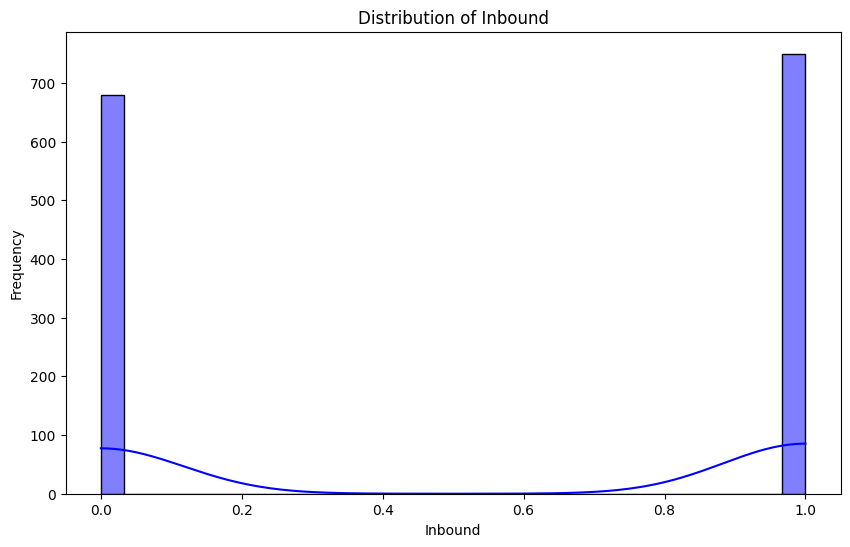

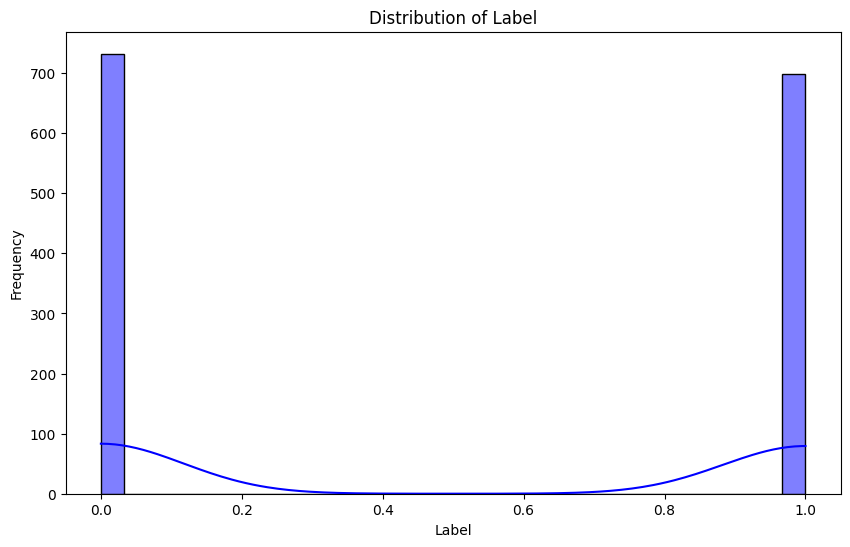

In [26]:
# Visualizing distributions for numerical features
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[col], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

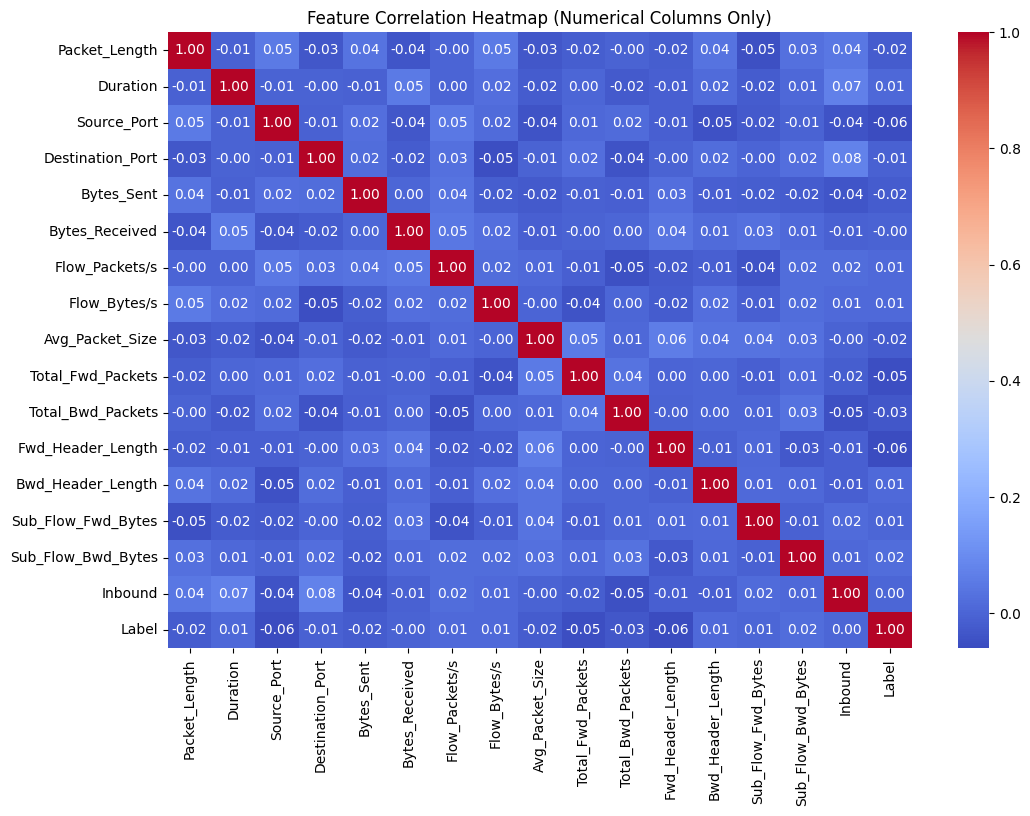

In [27]:
# ===============================
# 📈 Feature Correlation Analysis (Fixed)
# ===============================

# Selecting only numerical columns
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = data[numerical_columns].corr()

# Visualizing the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap (Numerical Columns Only)')
plt.show()


🗂 Unique Values in Timestamp:
Timestamp
2024-10-23 12:00:00    1
2024-10-23 12:15:39    1
2024-10-23 12:15:59    1
2024-10-23 12:15:58    1
2024-10-23 12:15:57    1
                      ..
2024-10-23 12:07:54    1
2024-10-23 12:07:53    1
2024-10-23 12:07:52    1
2024-10-23 12:07:51    1
2024-10-23 12:23:49    1
Name: count, Length: 1430, dtype: int64


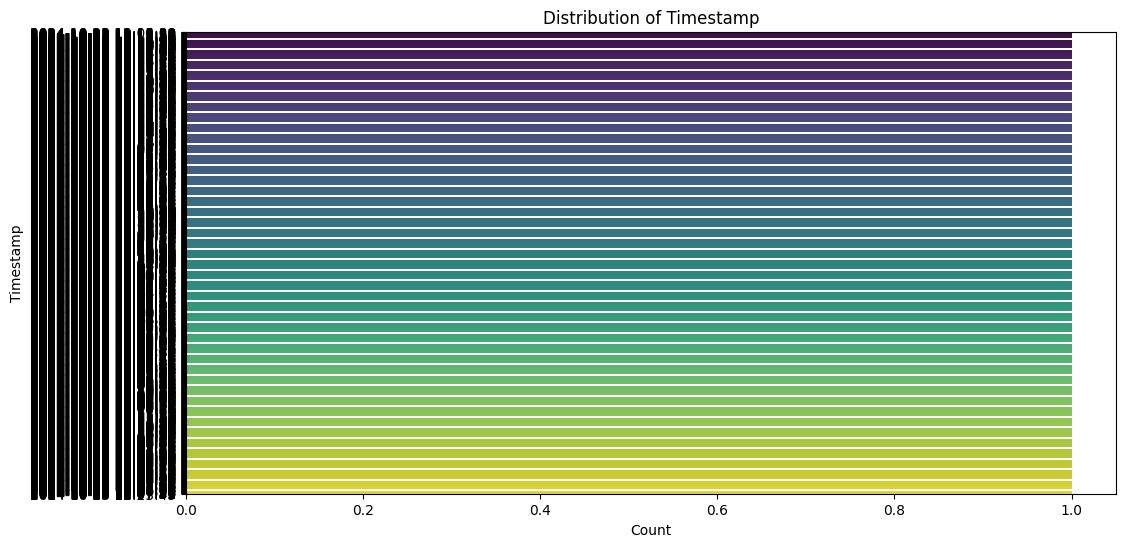


🗂 Unique Values in Source_IP:
Source_IP
192.168.0.1    291
192.168.0.7    160
172.16.0.3     156
172.16.0.4     143
10.0.0.5       143
10.0.0.9       139
172.16.0.10    139
192.168.0.8    133
10.0.0.6       126
Name: count, dtype: int64


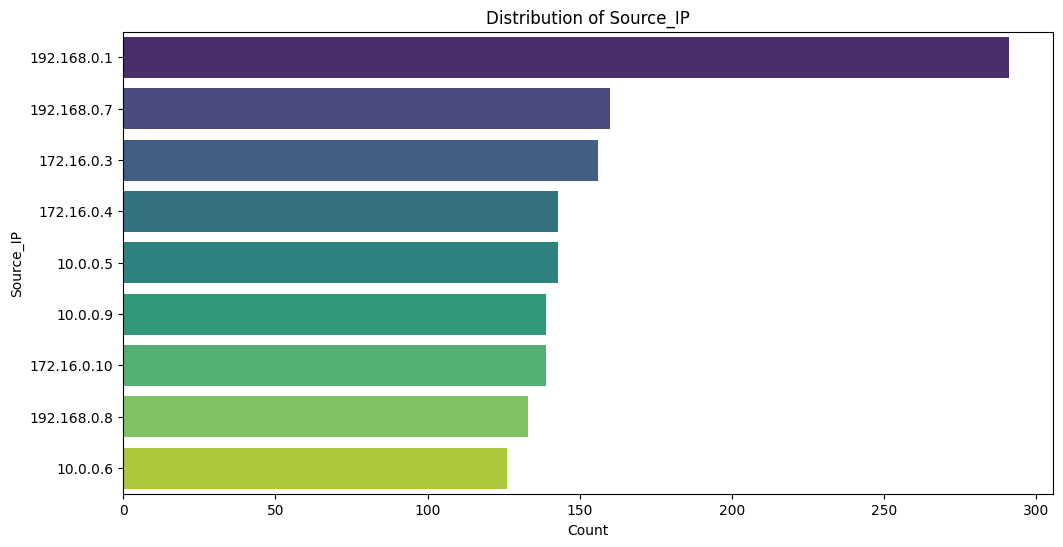


🗂 Unique Values in Destination_IP:
Destination_IP
10.0.0.3       340
192.168.0.2    314
172.16.0.5     283
172.16.0.4     191
10.0.0.4       182
192.168.0.1    120
Name: count, dtype: int64


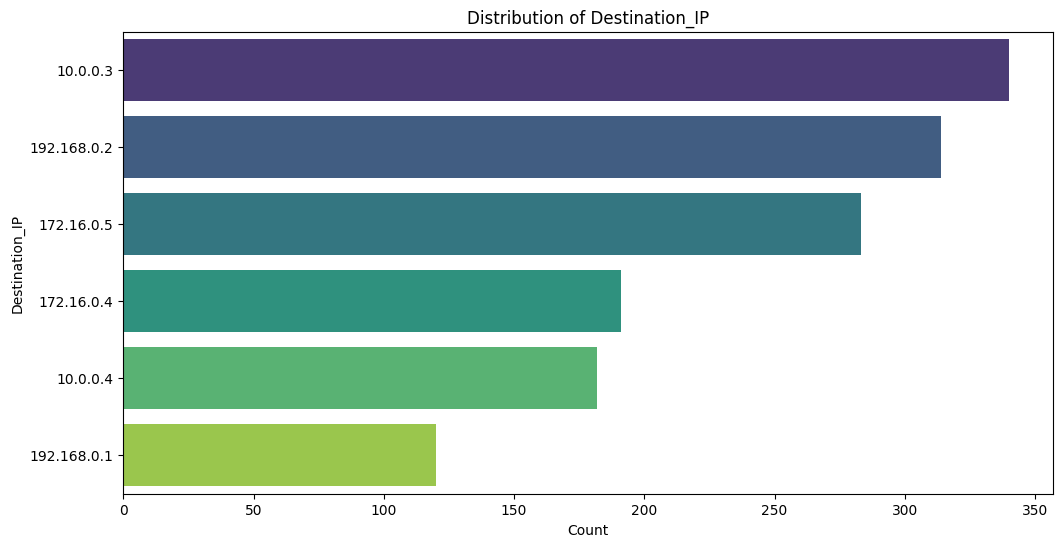


🗂 Unique Values in Protocol:
Protocol
UDP     502
ICMP    475
TCP     453
Name: count, dtype: int64


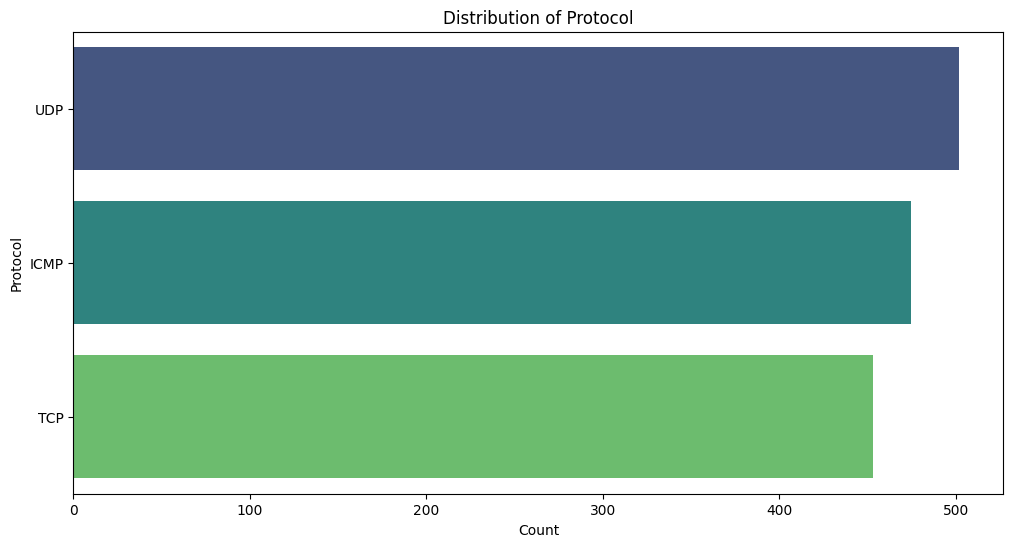


🗂 Unique Values in Flags:
Flags
ACK    381
PSH    356
FIN    348
SYN    345
Name: count, dtype: int64


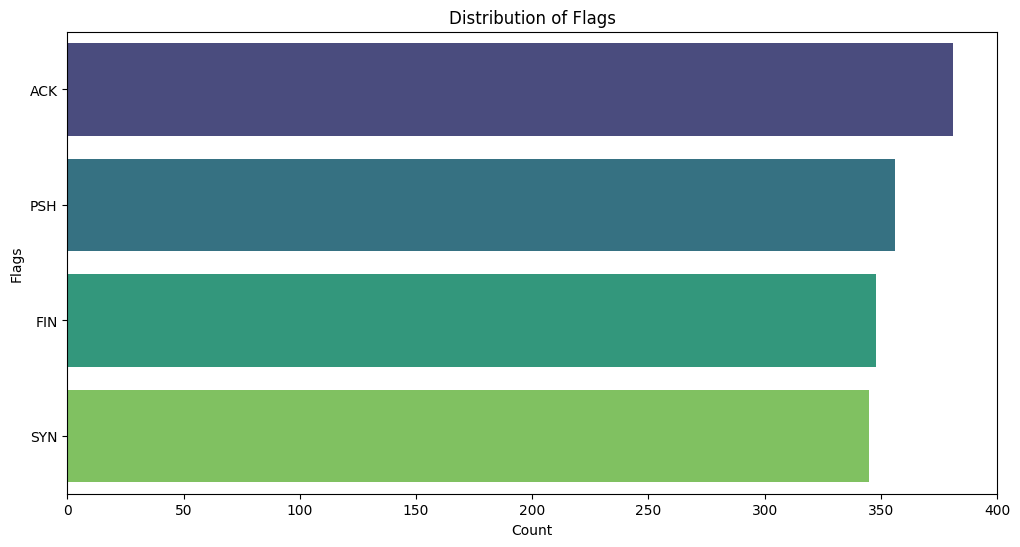


🗂 Unique Values in Attack_Type:
Attack_Type
DDoS           377
Ransomware     361
Brute Force    352
Normal         340
Name: count, dtype: int64


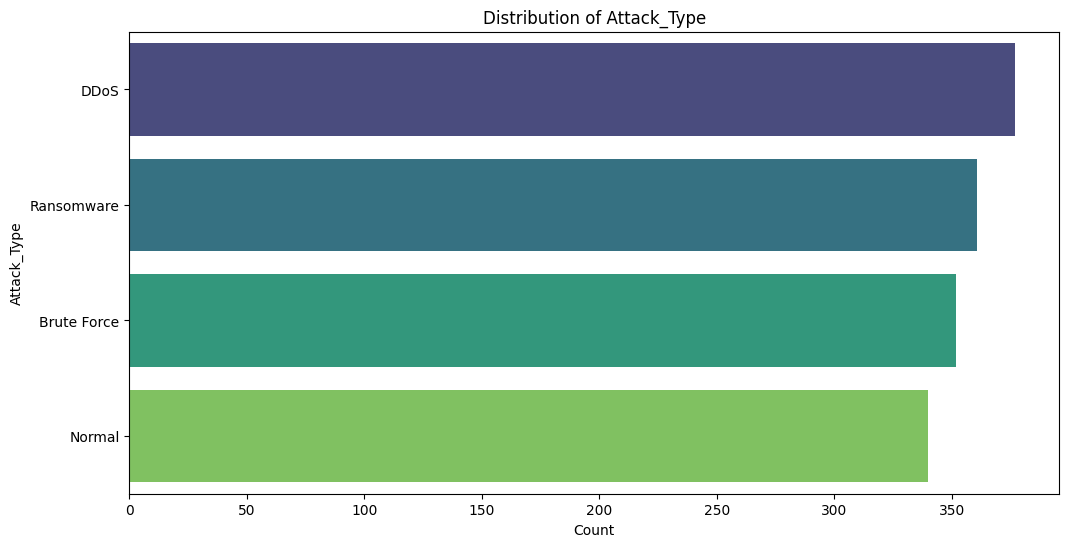

In [28]:
# ===============================
# 🔗 Advanced Categorical Insights
# ===============================

categorical_columns = data.select_dtypes(include=['object']).columns

for col in categorical_columns:
    print(f"\n🗂 Unique Values in {col}:")
    print(data[col].value_counts())

    plt.figure(figsize=(12, 6))
    sns.countplot(data=data, y=col, order=data[col].value_counts().index, palette="viridis")
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()


⚠️ Outliers detected in Packet_Length: 0


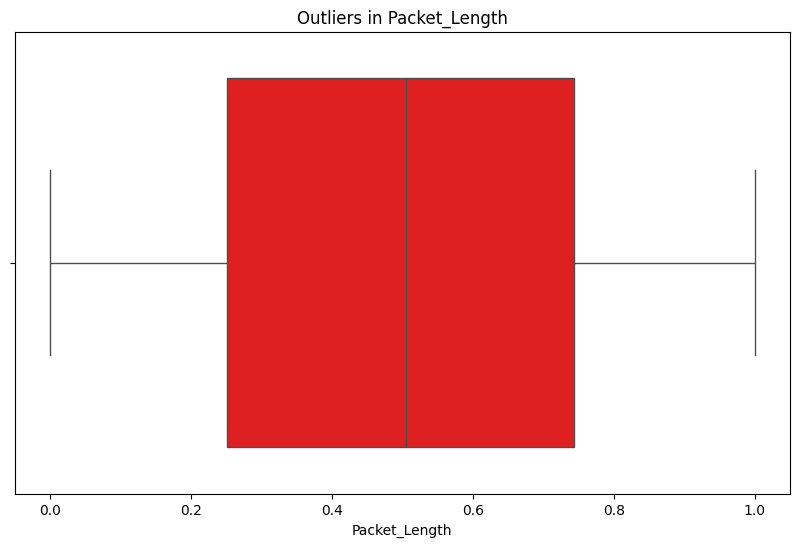


⚠️ Outliers detected in Duration: 0


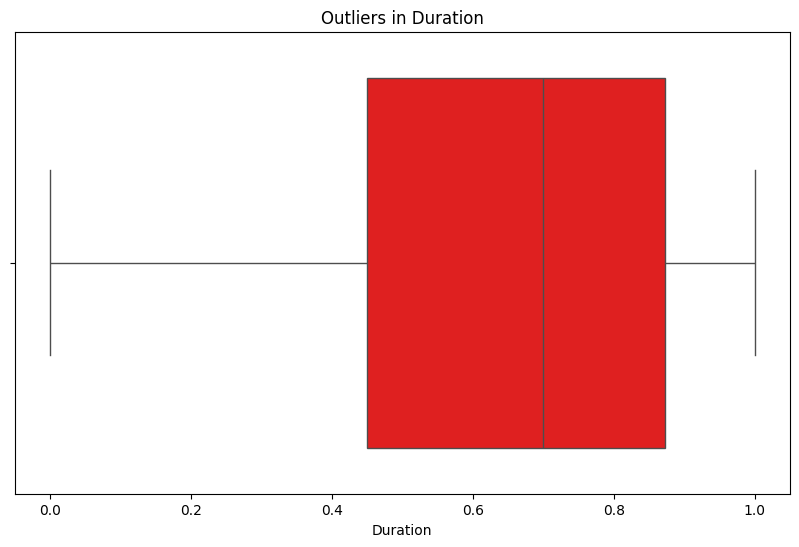


⚠️ Outliers detected in Source_Port: 0


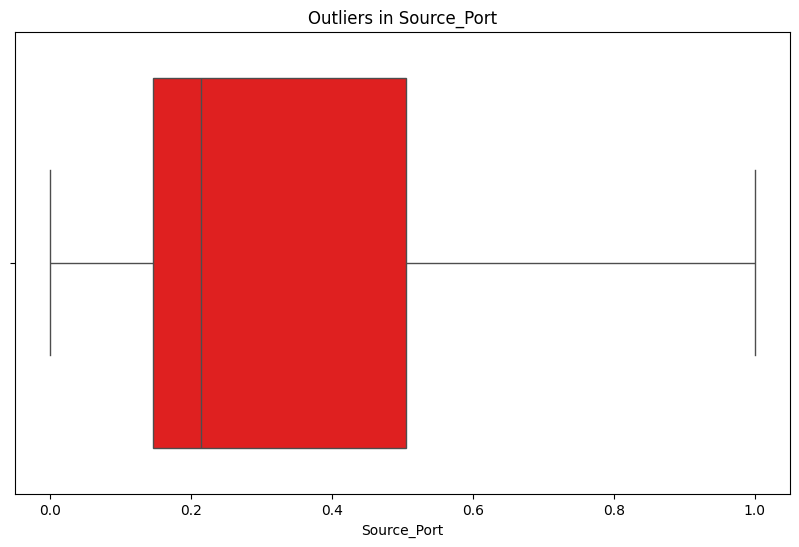


⚠️ Outliers detected in Destination_Port: 0


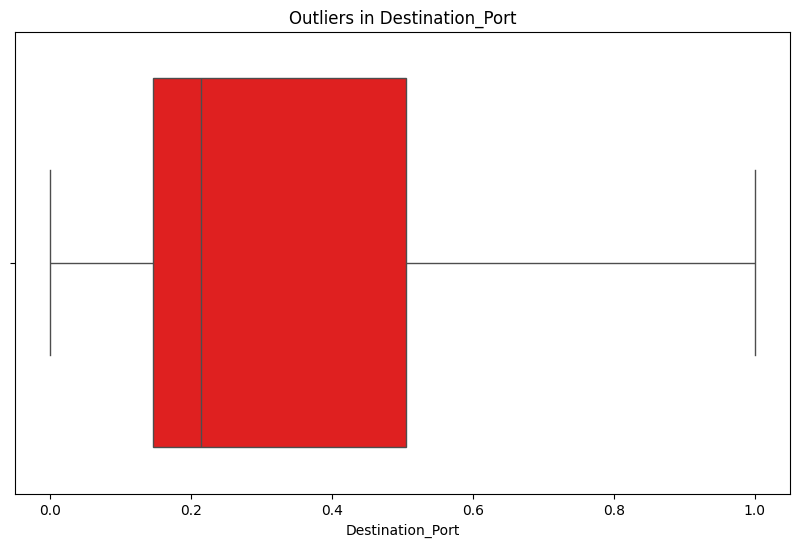


⚠️ Outliers detected in Bytes_Sent: 0


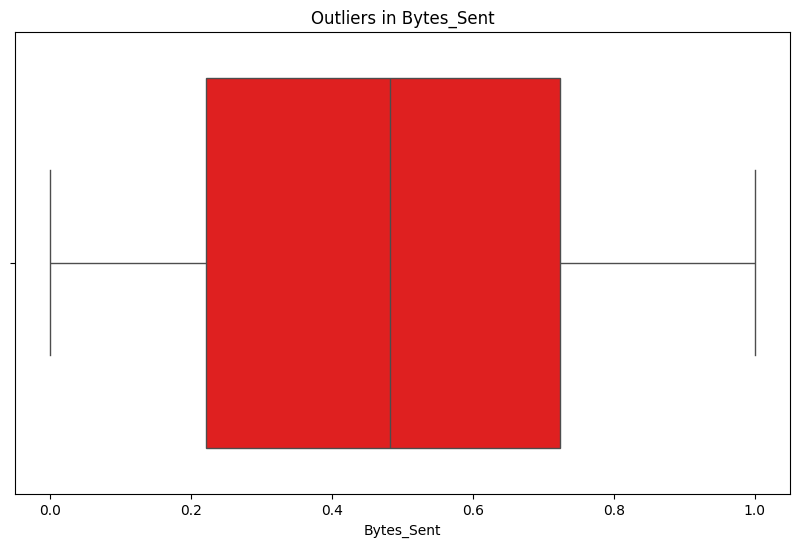


⚠️ Outliers detected in Bytes_Received: 0


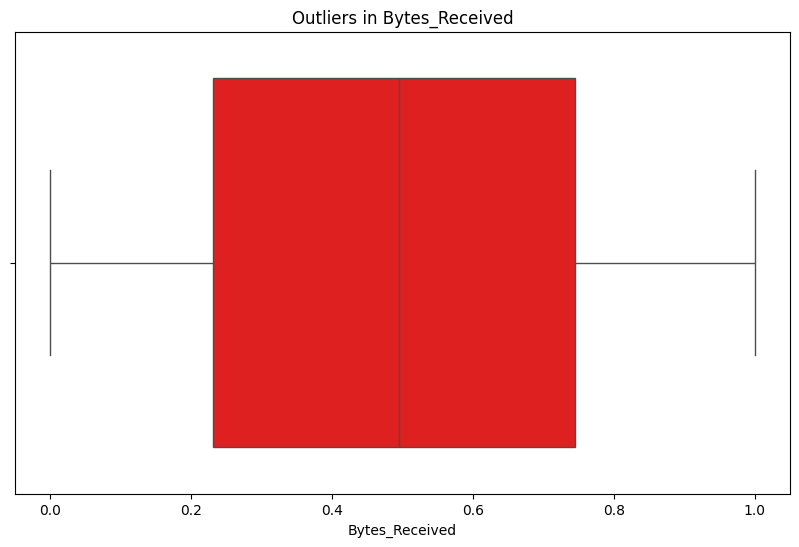


⚠️ Outliers detected in Flow_Packets/s: 0


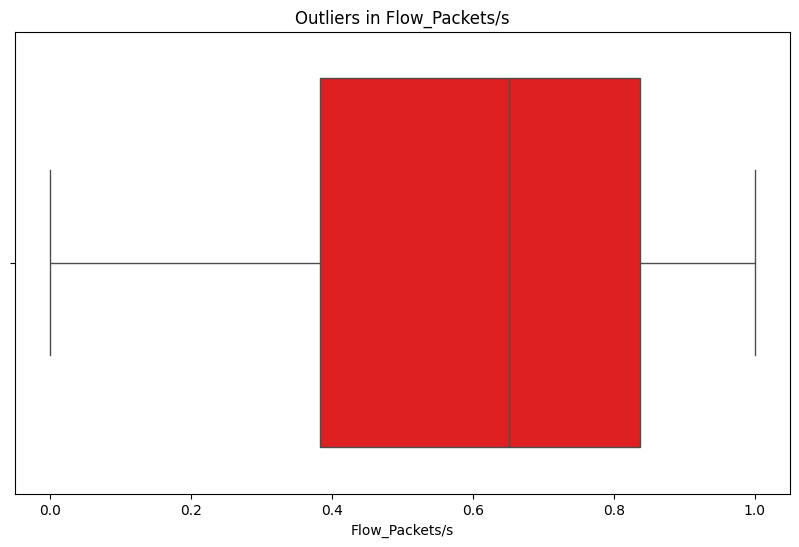


⚠️ Outliers detected in Flow_Bytes/s: 0


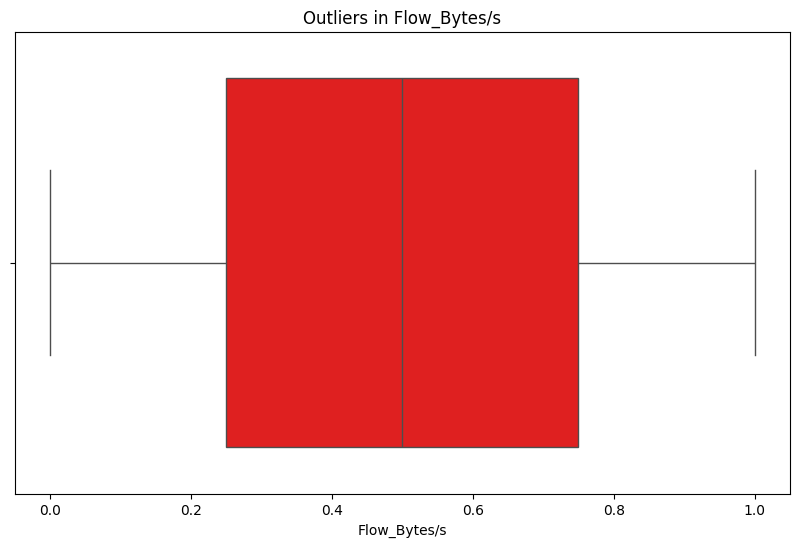


⚠️ Outliers detected in Avg_Packet_Size: 0


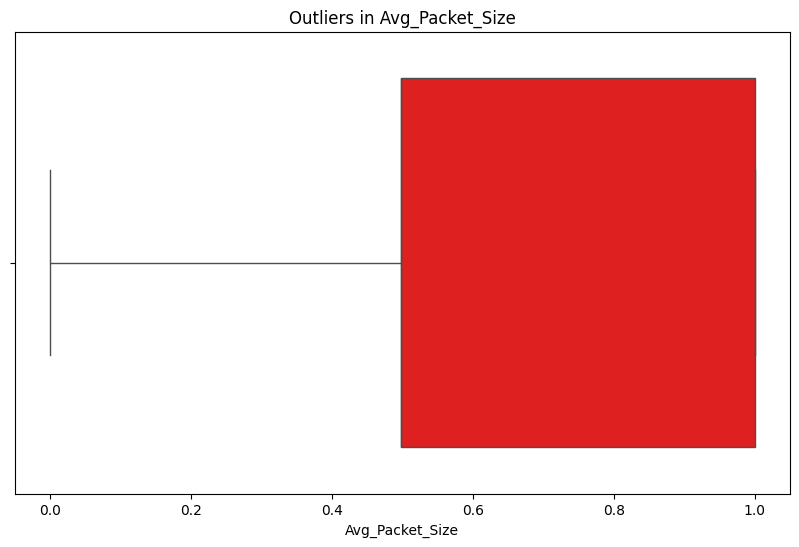


⚠️ Outliers detected in Total_Fwd_Packets: 0


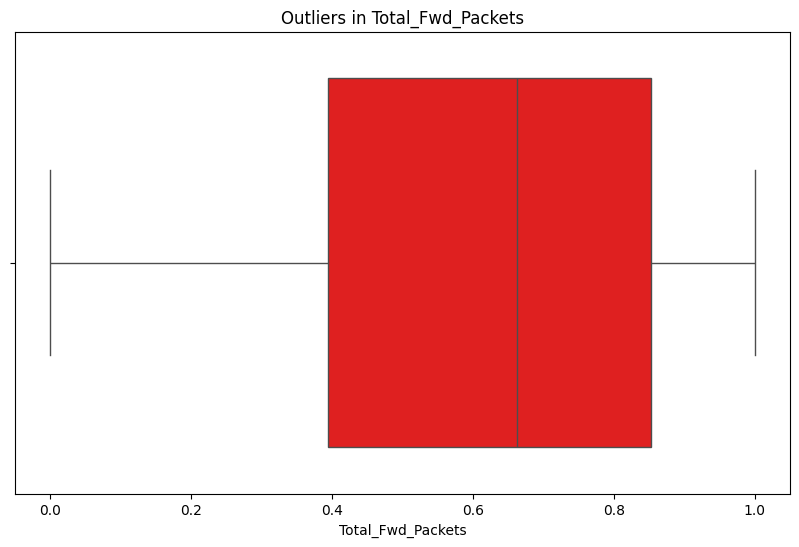


⚠️ Outliers detected in Total_Bwd_Packets: 0


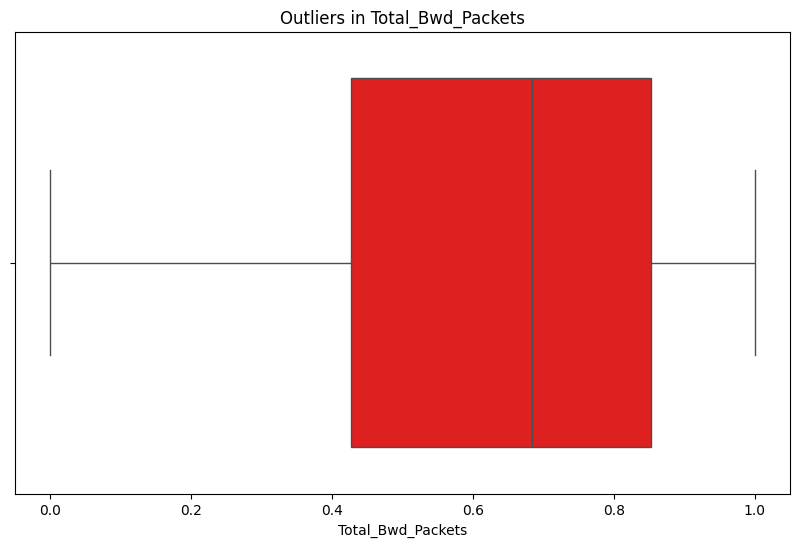


⚠️ Outliers detected in Fwd_Header_Length: 0


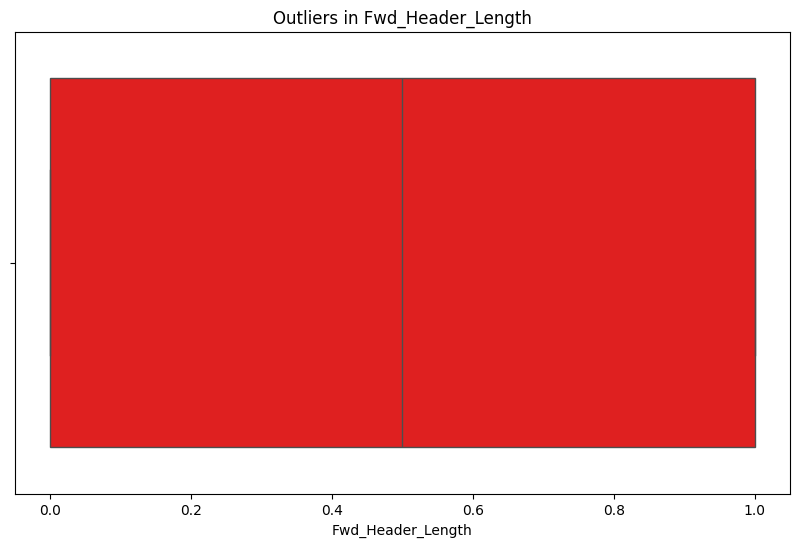


⚠️ Outliers detected in Bwd_Header_Length: 0


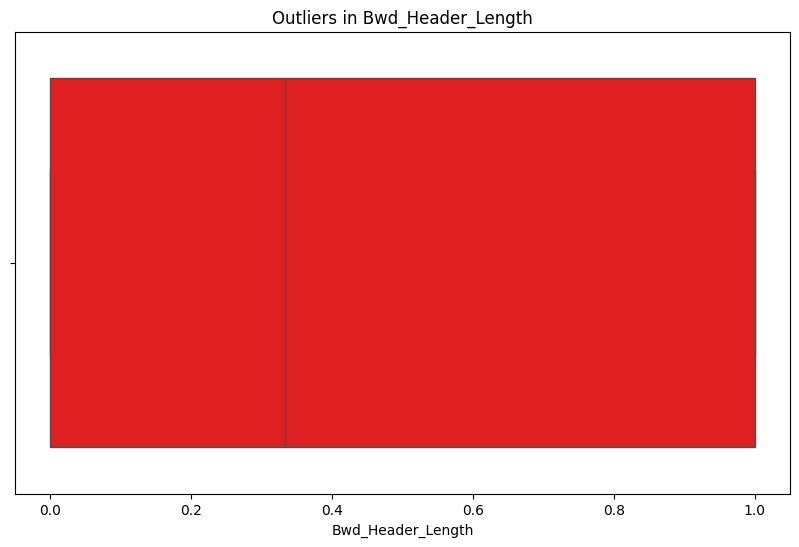


⚠️ Outliers detected in Sub_Flow_Fwd_Bytes: 0


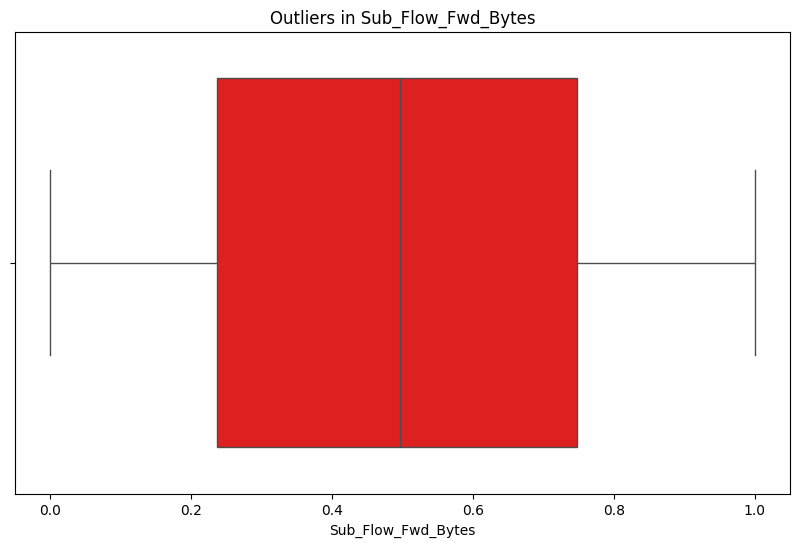


⚠️ Outliers detected in Sub_Flow_Bwd_Bytes: 0


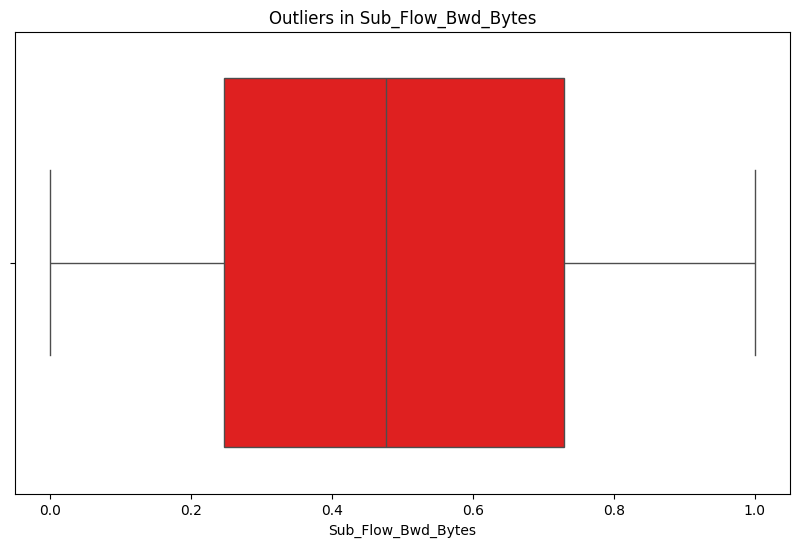


⚠️ Outliers detected in Inbound: 0


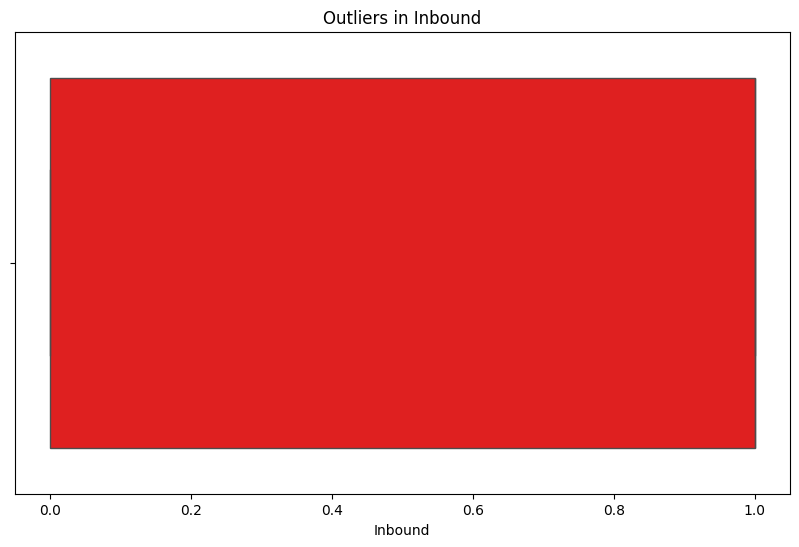


⚠️ Outliers detected in Label: 0


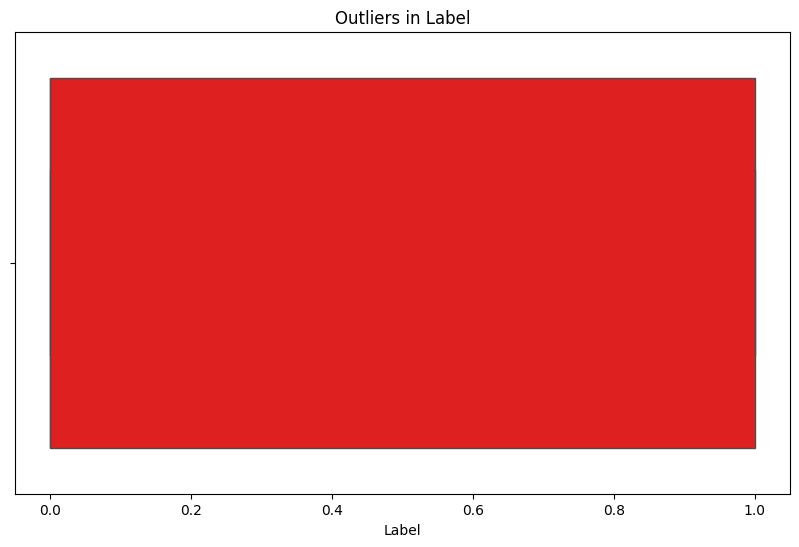

In [29]:
# ===============================
# ⚠️ Advanced Anomaly Detection
# ===============================

# Using Z-score for outlier detection
from scipy.stats import zscore

for col in numerical_columns:
    z_scores = zscore(data[col])
    outliers = data[np.abs(z_scores) > 3]
    print(f"\n⚠️ Outliers detected in {col}: {len(outliers)}")

    # Visualizing outliers
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data, x=col, color="red")
    plt.title(f'Outliers in {col}')
    plt.show()

In [33]:
# ===============================
# 📌 Insights and Next Steps
# ===============================
print("\n✅ Advanced data exploration completed! Use these insights to guide feature engineering and model selection.")


✅ Advanced data exploration completed! Use these insights to guide feature engineering and model selection.



📈 Descriptive Statistics for Numerical Features:
       Packet_Length     Duration  Source_Port  Destination_Port   Bytes_Sent  \
count    1430.000000  1430.000000  1430.000000       1430.000000  1430.000000   
mean        0.504803     0.641130     0.369891          0.370080     0.480253   
std         0.288818     0.269931     0.349908          0.365590     0.287576   
min         0.000000     0.000000     0.000000          0.000000     0.000000   
25%         0.251261     0.449970     0.145603          0.145603     0.221212   
50%         0.505550     0.699703     0.214774          0.214774     0.481818   
75%         0.744198     0.873356     0.505023          0.505023     0.723232   
max         1.000000     1.000000     1.000000          1.000000     1.000000   

       Bytes_Received  Flow_Packets/s  Flow_Bytes/s  Avg_Packet_Size  \
count     1430.000000     1430.000000   1430.000000      1430.000000   
mean         0.495723        0.598513      0.498249         0.560527   
std 

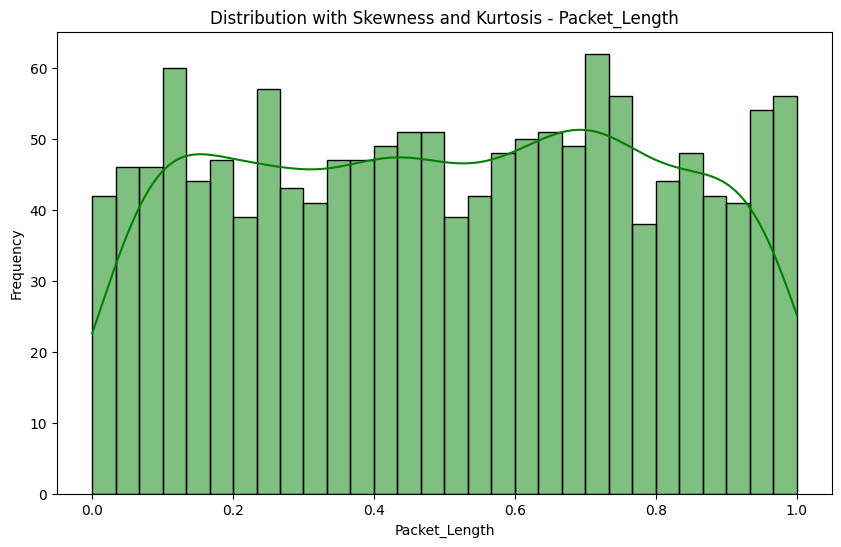


🔹 Feature: Duration
   Skewness: -0.621 (Distribution asymmetry)
   Kurtosis: -0.660 (Tail heaviness)


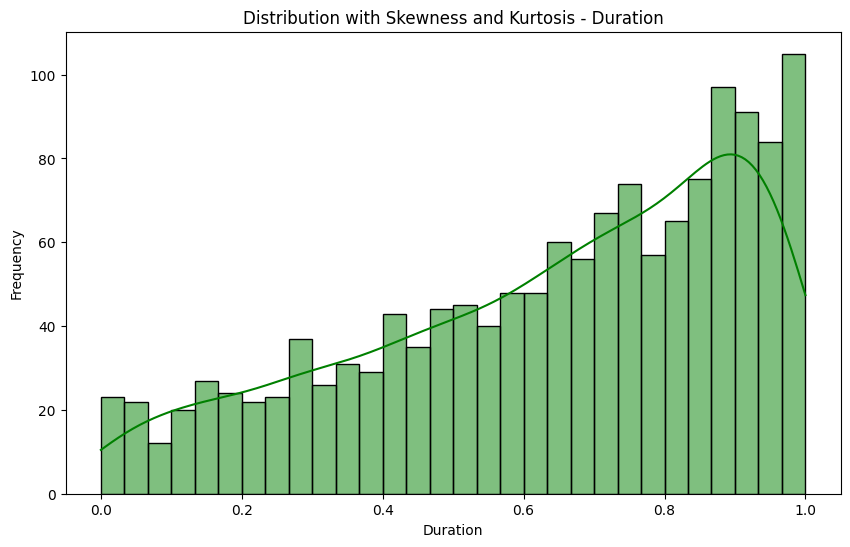


🔹 Feature: Source_Port
   Skewness: 0.823 (Distribution asymmetry)
   Kurtosis: -0.683 (Tail heaviness)


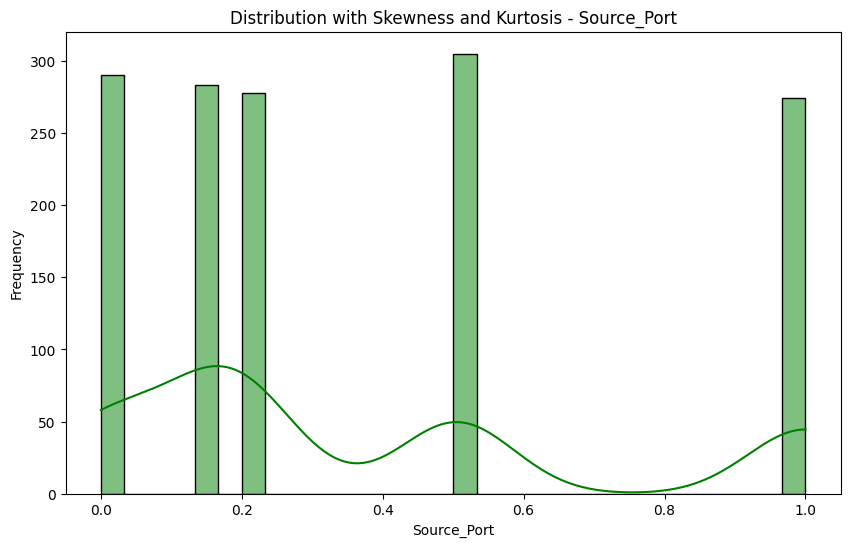


🔹 Feature: Destination_Port
   Skewness: 0.826 (Distribution asymmetry)
   Kurtosis: -0.825 (Tail heaviness)


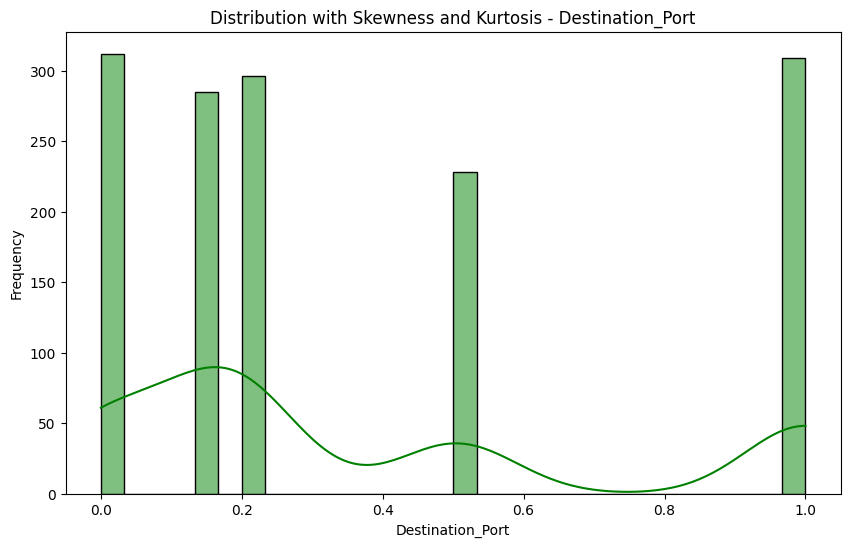


🔹 Feature: Bytes_Sent
   Skewness: 0.054 (Distribution asymmetry)
   Kurtosis: -1.185 (Tail heaviness)


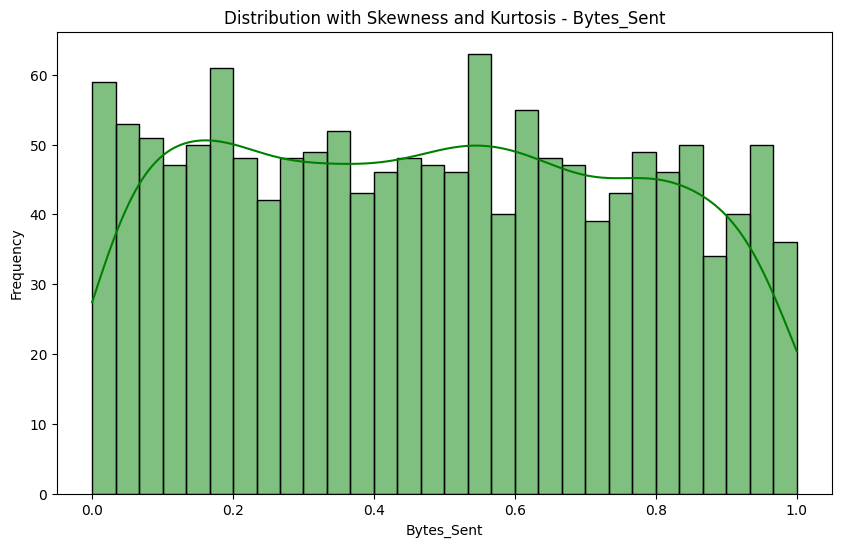


🔹 Feature: Bytes_Received
   Skewness: -0.000 (Distribution asymmetry)
   Kurtosis: -1.207 (Tail heaviness)


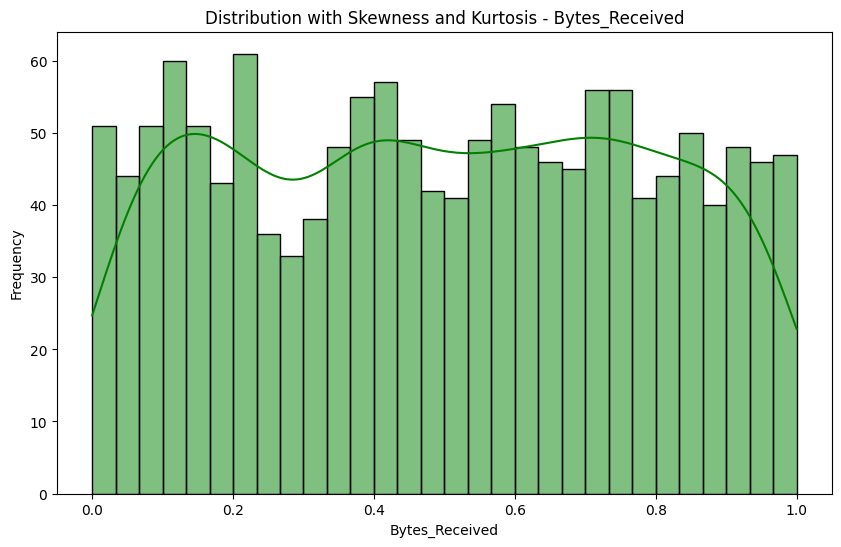


🔹 Feature: Flow_Packets/s
   Skewness: -0.434 (Distribution asymmetry)
   Kurtosis: -0.977 (Tail heaviness)


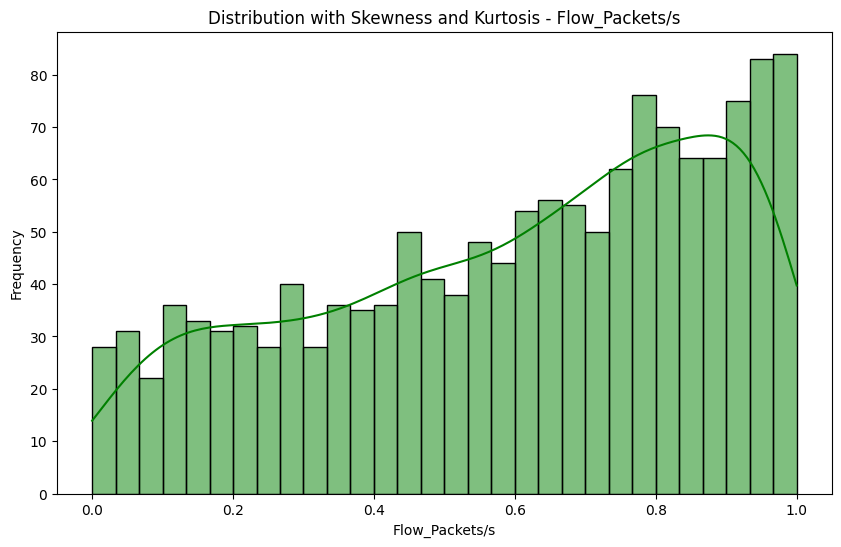


🔹 Feature: Flow_Bytes/s
   Skewness: 0.006 (Distribution asymmetry)
   Kurtosis: -1.200 (Tail heaviness)


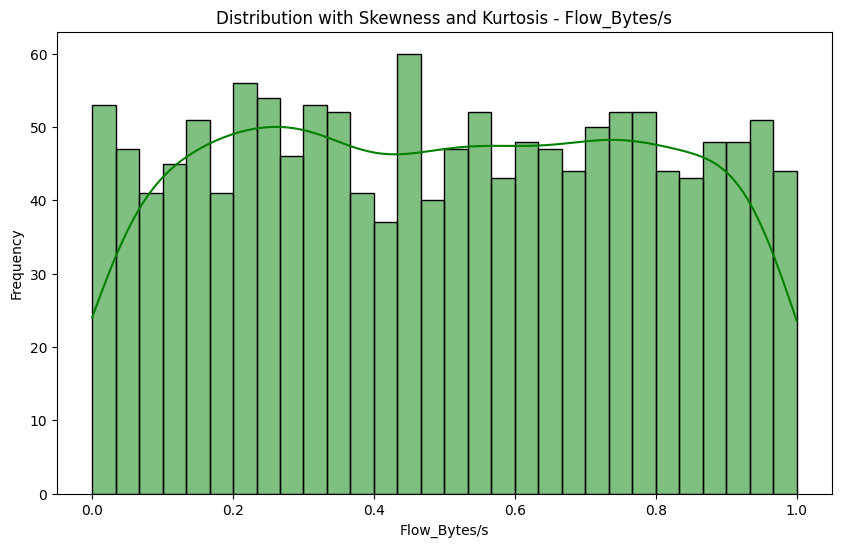


🔹 Feature: Avg_Packet_Size
   Skewness: -0.405 (Distribution asymmetry)
   Kurtosis: -1.119 (Tail heaviness)


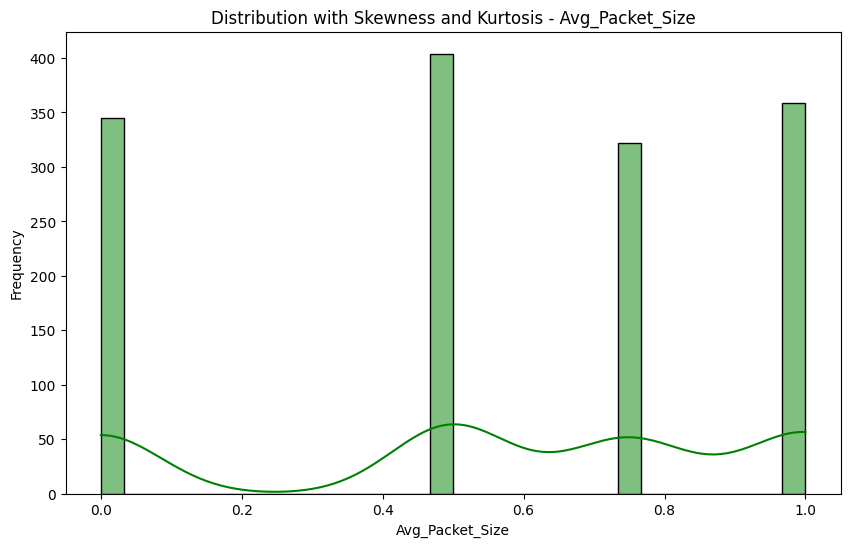


🔹 Feature: Total_Fwd_Packets
   Skewness: -0.510 (Distribution asymmetry)
   Kurtosis: -0.815 (Tail heaviness)


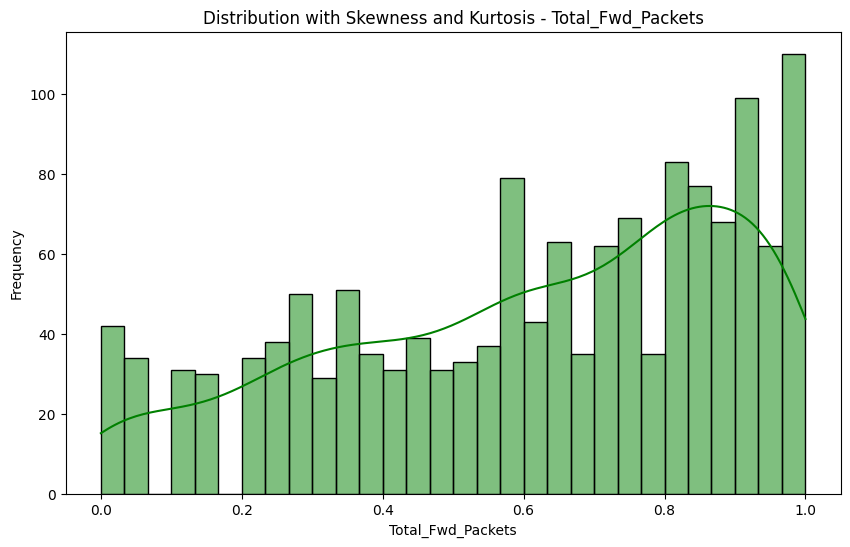


🔹 Feature: Total_Bwd_Packets
   Skewness: -0.549 (Distribution asymmetry)
   Kurtosis: -0.688 (Tail heaviness)


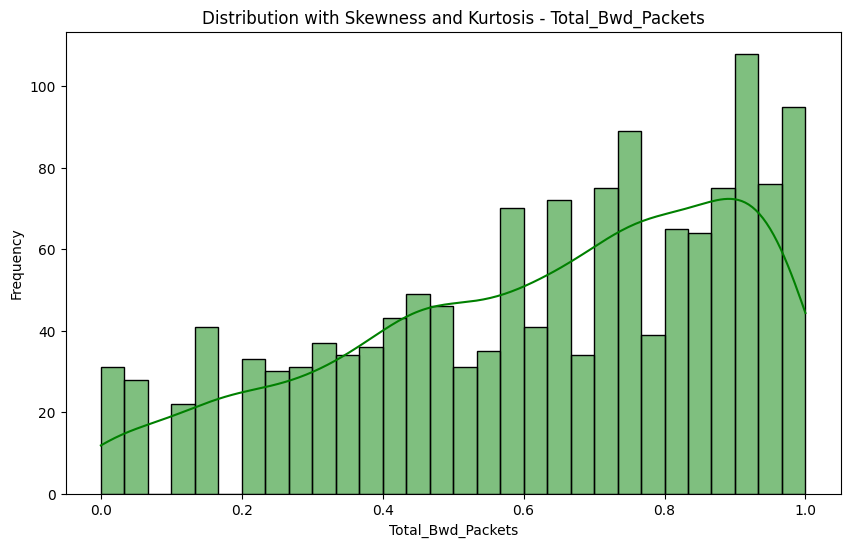


🔹 Feature: Fwd_Header_Length
   Skewness: -0.081 (Distribution asymmetry)
   Kurtosis: -1.458 (Tail heaviness)


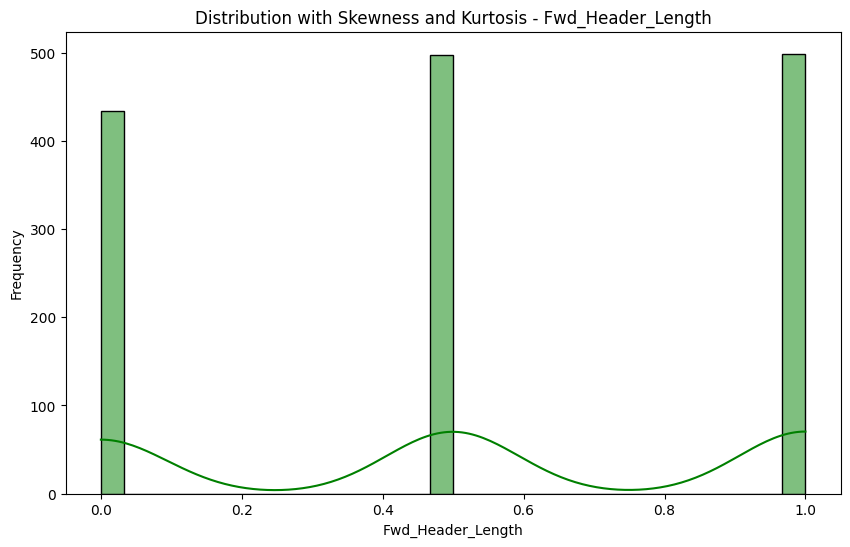


🔹 Feature: Bwd_Header_Length
   Skewness: 0.404 (Distribution asymmetry)
   Kurtosis: -1.492 (Tail heaviness)


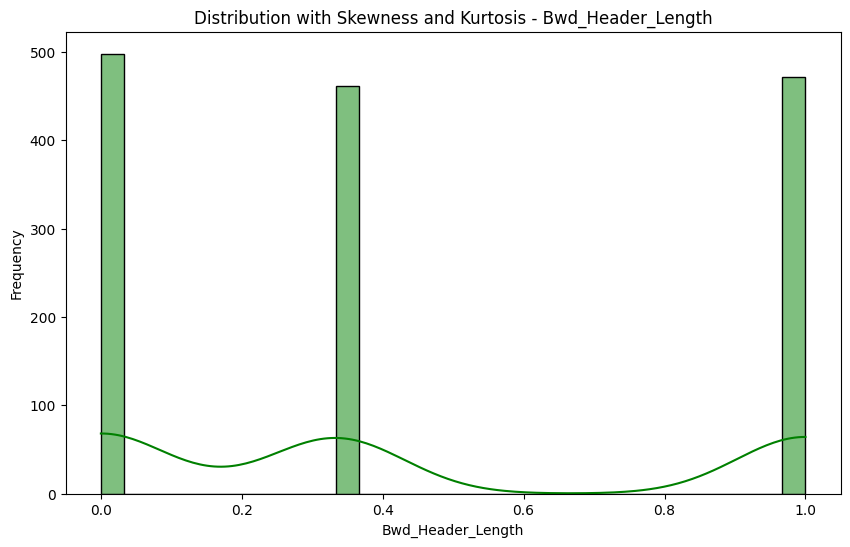


🔹 Feature: Sub_Flow_Fwd_Bytes
   Skewness: 0.005 (Distribution asymmetry)
   Kurtosis: -1.214 (Tail heaviness)


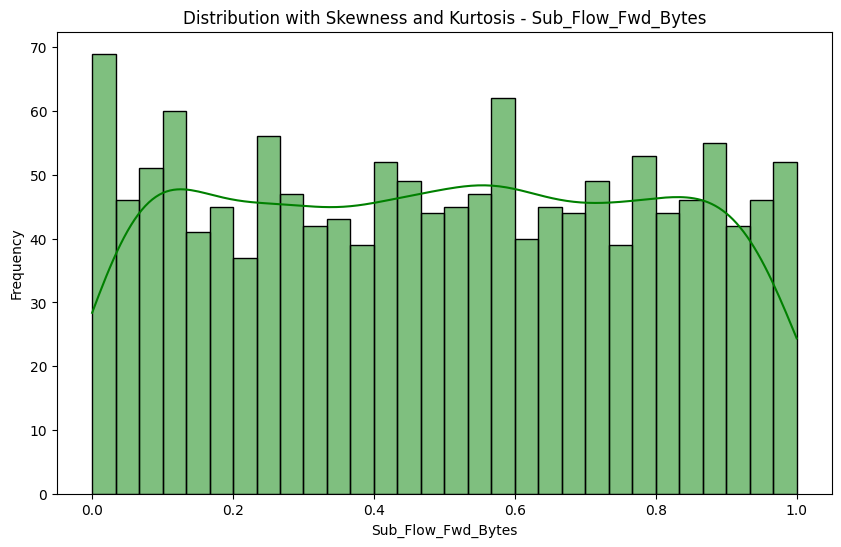


🔹 Feature: Sub_Flow_Bwd_Bytes
   Skewness: 0.044 (Distribution asymmetry)
   Kurtosis: -1.153 (Tail heaviness)


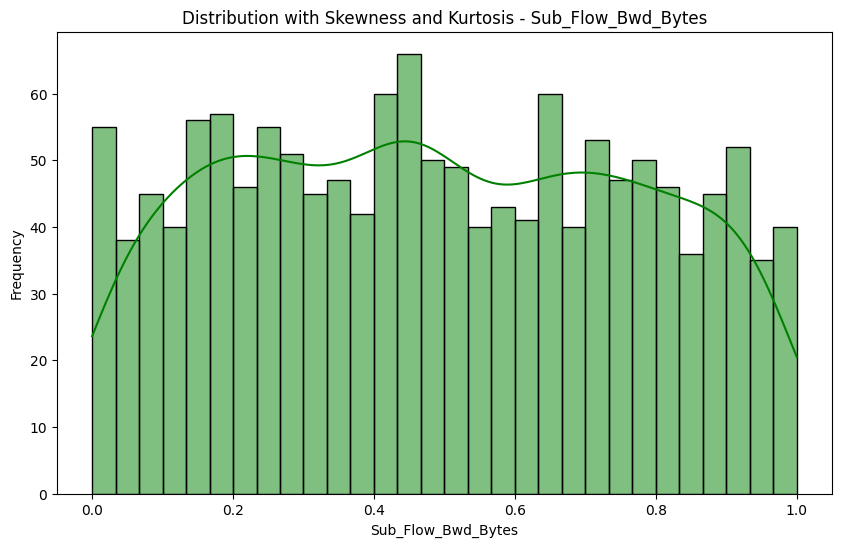


🔹 Feature: Inbound
   Skewness: -0.098 (Distribution asymmetry)
   Kurtosis: -1.990 (Tail heaviness)


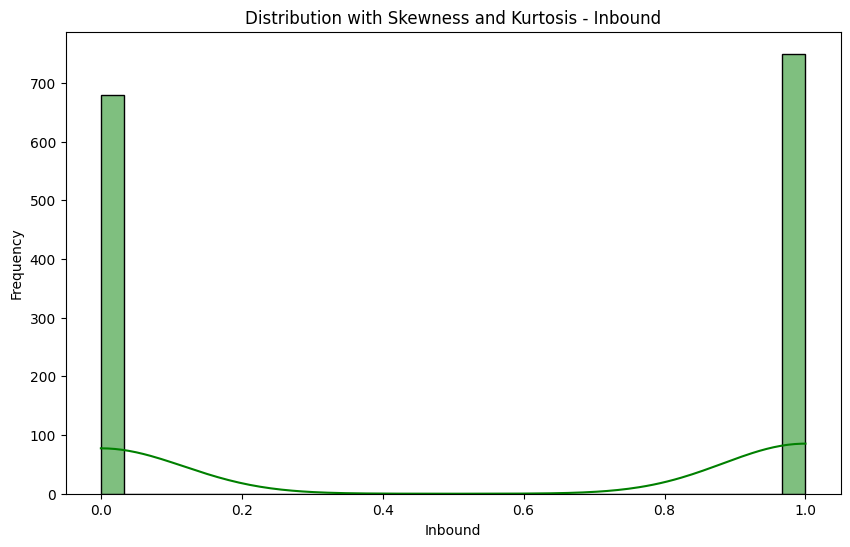


🔹 Feature: Label
   Skewness: 0.048 (Distribution asymmetry)
   Kurtosis: -1.998 (Tail heaviness)


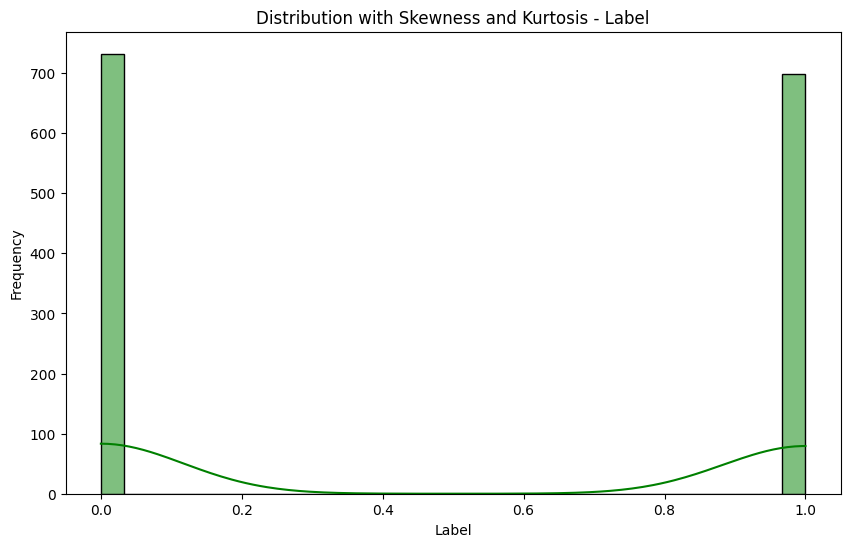

In [35]:

# ===============================
# 📊 Descriptive Statistics
# ===============================

print("\n📈 Descriptive Statistics for Numerical Features:")
print(data.describe())

# Visualizing skewness and kurtosis for numerical features
from scipy.stats import skew, kurtosis

for col in numerical_columns:
    col_skew = skew(data[col].dropna())
    col_kurt = kurtosis(data[col].dropna())
    print(f"\n🔹 Feature: {col}")
    print(f"   Skewness: {col_skew:.3f} (Distribution asymmetry)")
    print(f"   Kurtosis: {col_kurt:.3f} (Tail heaviness)")

    # Histogram and KDE plot
    plt.figure(figsize=(10, 6))
    sns.histplot(data[col], kde=True, bins=30, color='green')
    plt.title(f'Distribution with Skewness and Kurtosis - {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


⚠️ Outliers in Packet_Length: 0


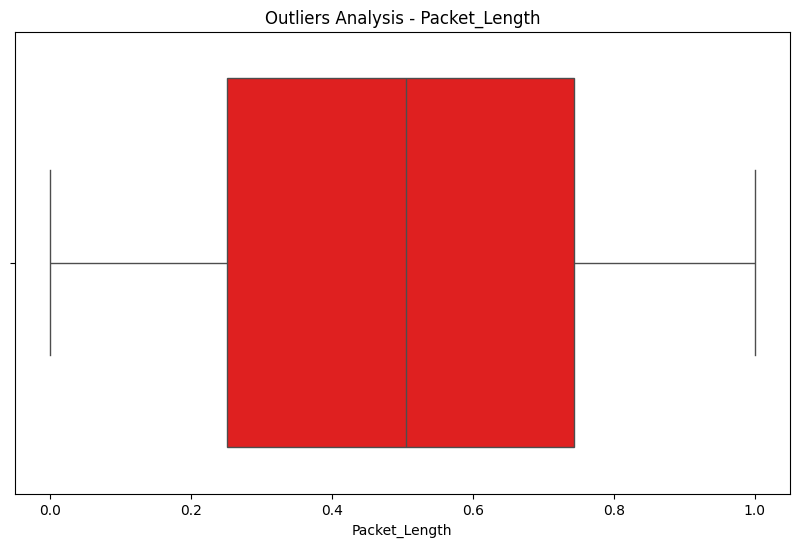


⚠️ Outliers in Duration: 0


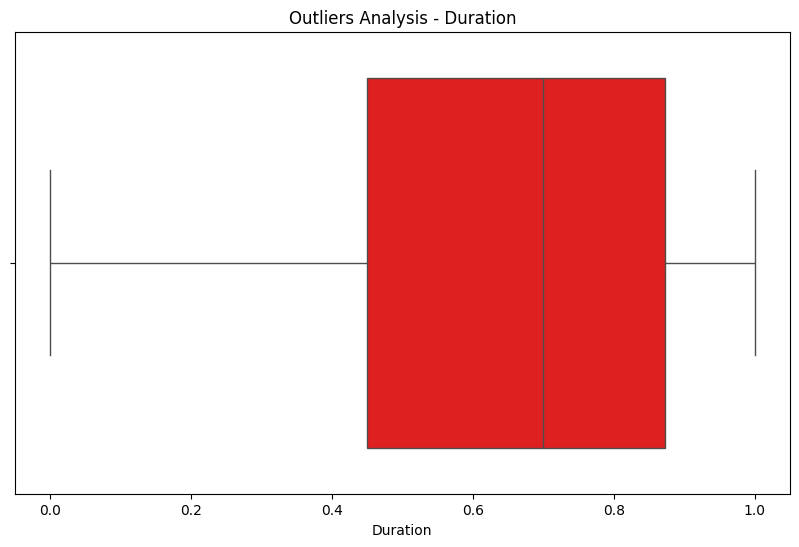


⚠️ Outliers in Source_Port: 0


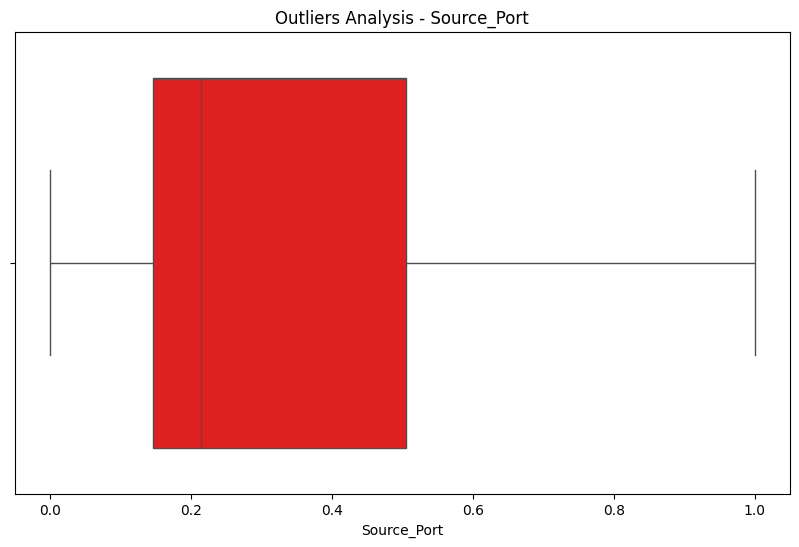


⚠️ Outliers in Destination_Port: 0


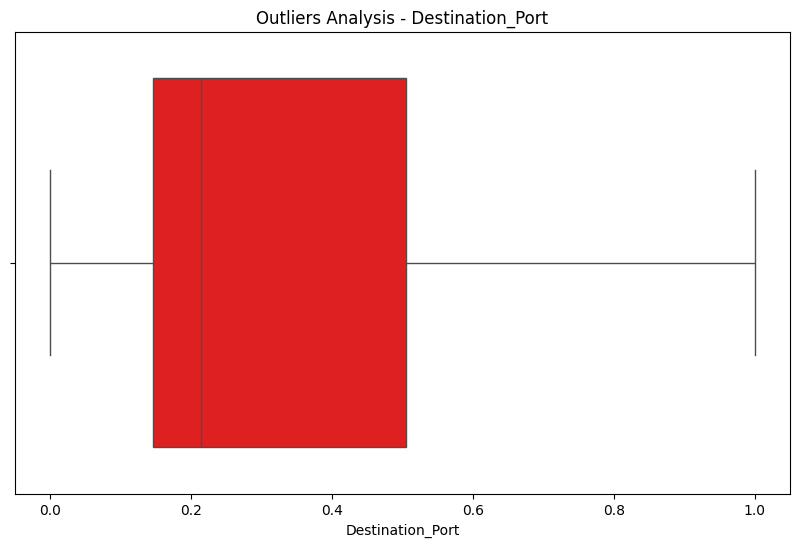


⚠️ Outliers in Bytes_Sent: 0


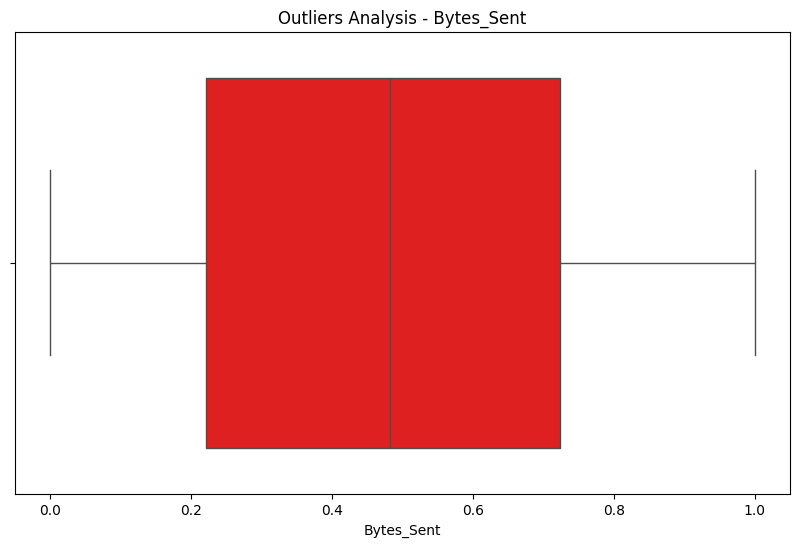


⚠️ Outliers in Bytes_Received: 0


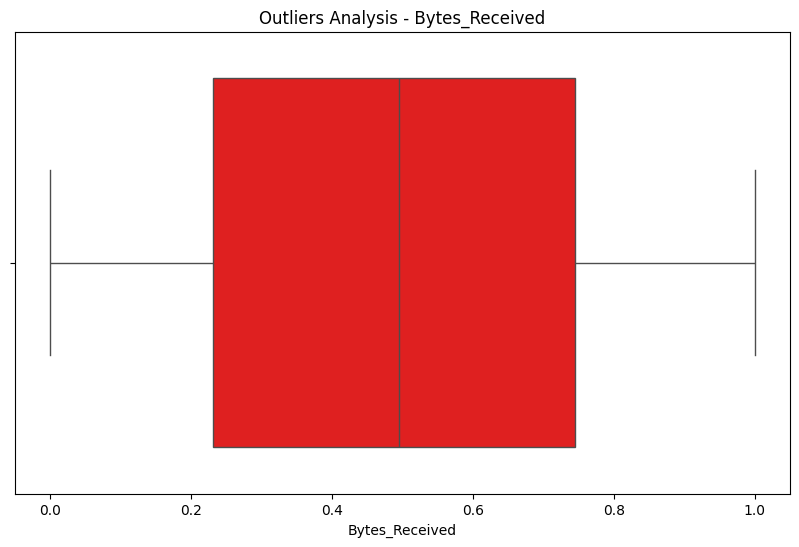


⚠️ Outliers in Flow_Packets/s: 0


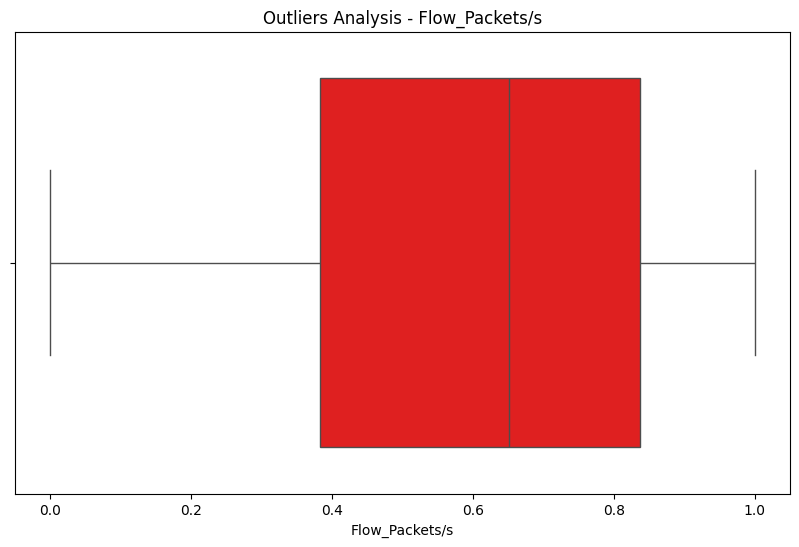


⚠️ Outliers in Flow_Bytes/s: 0


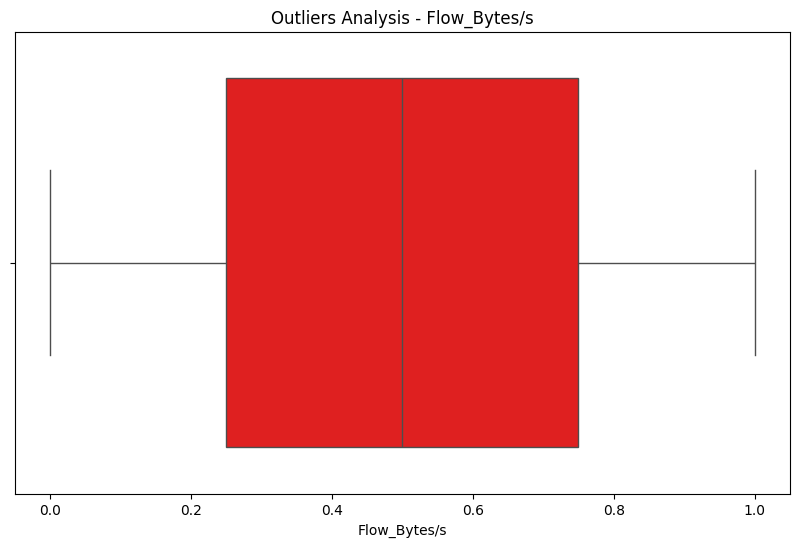


⚠️ Outliers in Avg_Packet_Size: 0


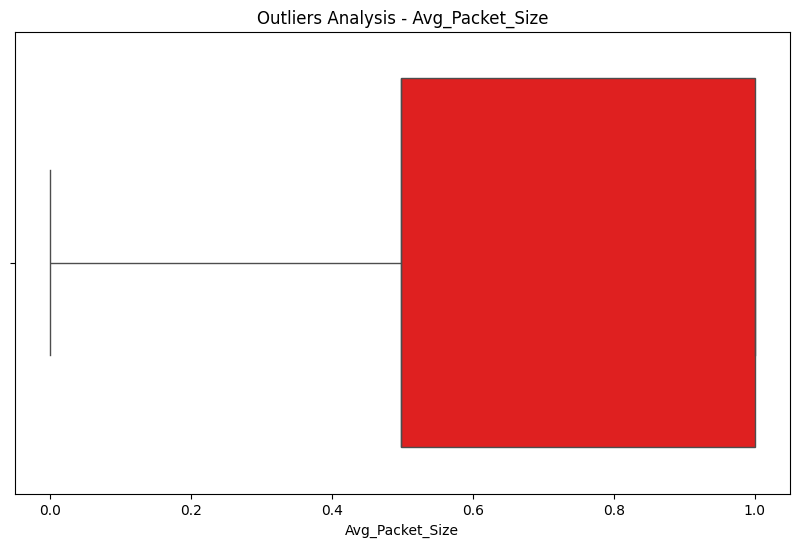


⚠️ Outliers in Total_Fwd_Packets: 0


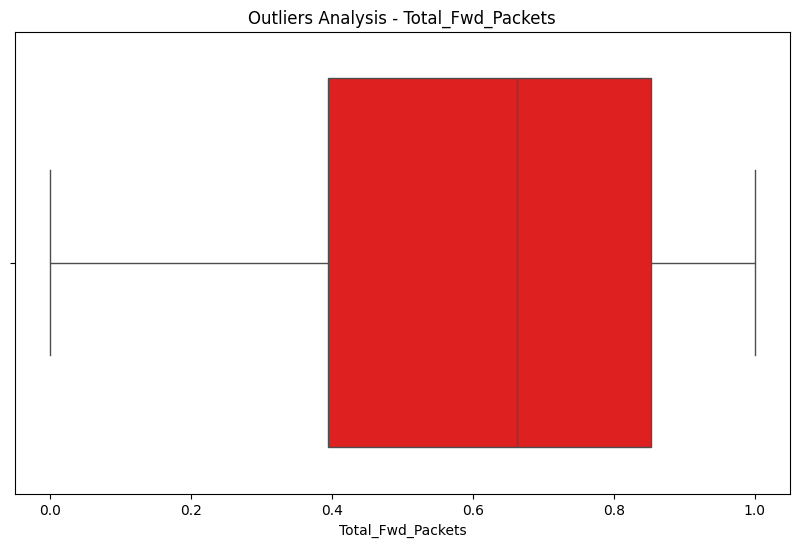


⚠️ Outliers in Total_Bwd_Packets: 0


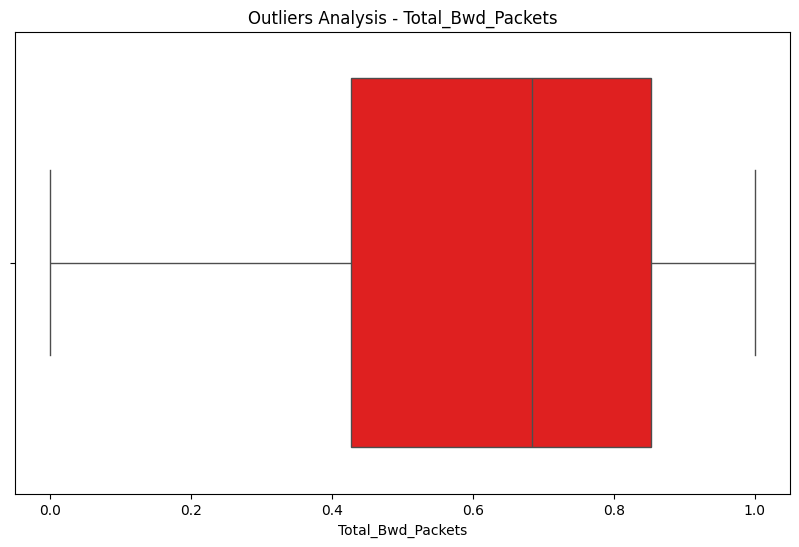


⚠️ Outliers in Fwd_Header_Length: 0


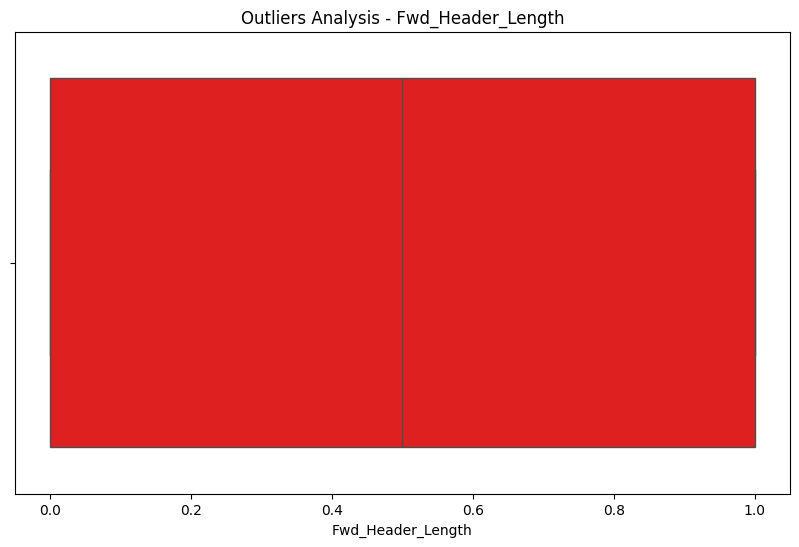


⚠️ Outliers in Bwd_Header_Length: 0


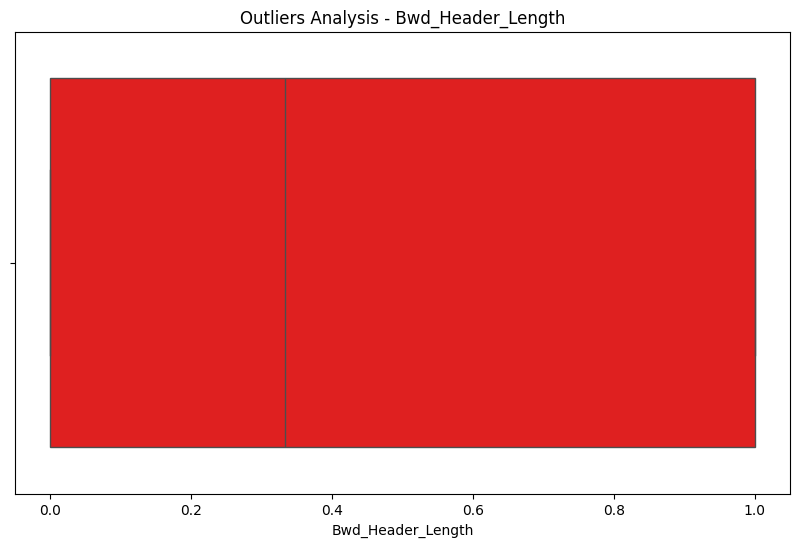


⚠️ Outliers in Sub_Flow_Fwd_Bytes: 0


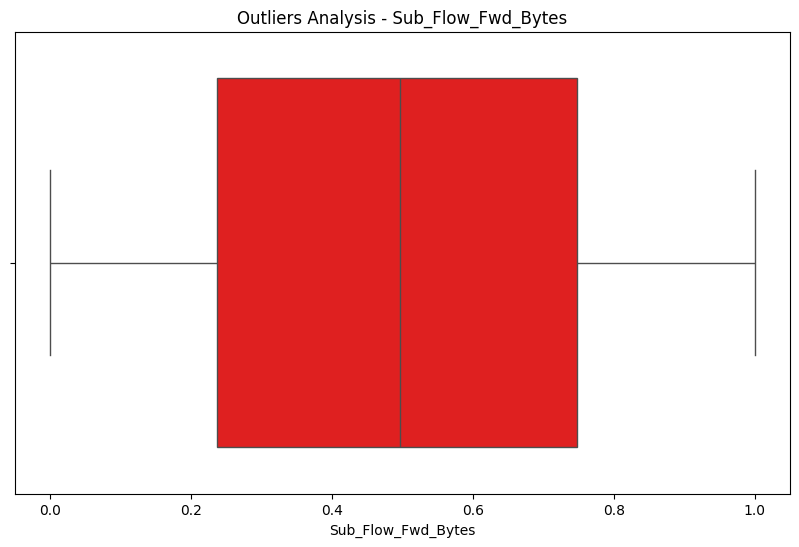


⚠️ Outliers in Sub_Flow_Bwd_Bytes: 0


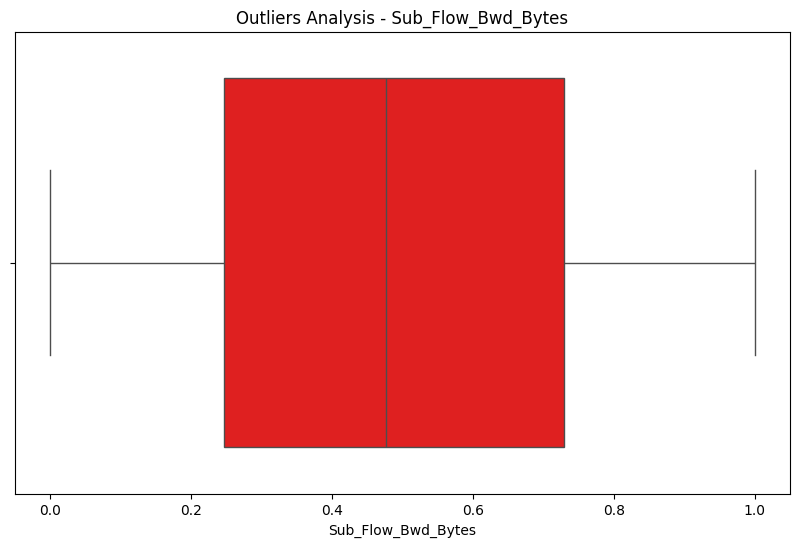


⚠️ Outliers in Inbound: 0


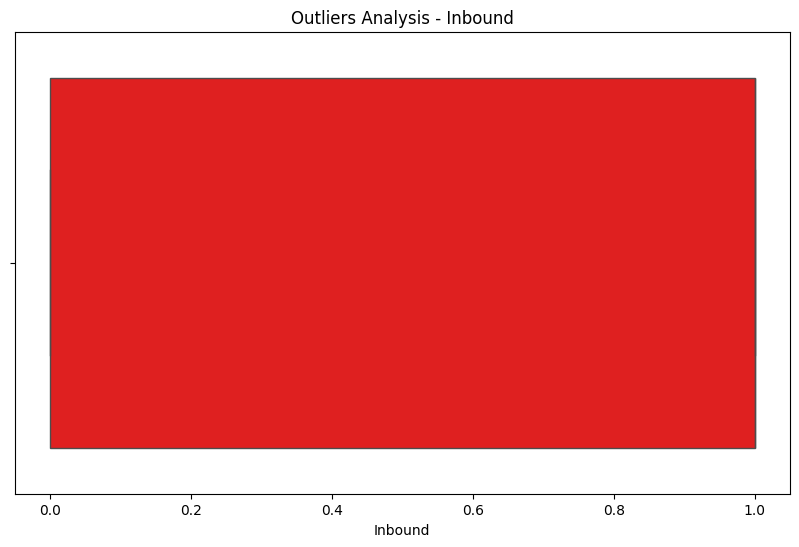


⚠️ Outliers in Label: 0


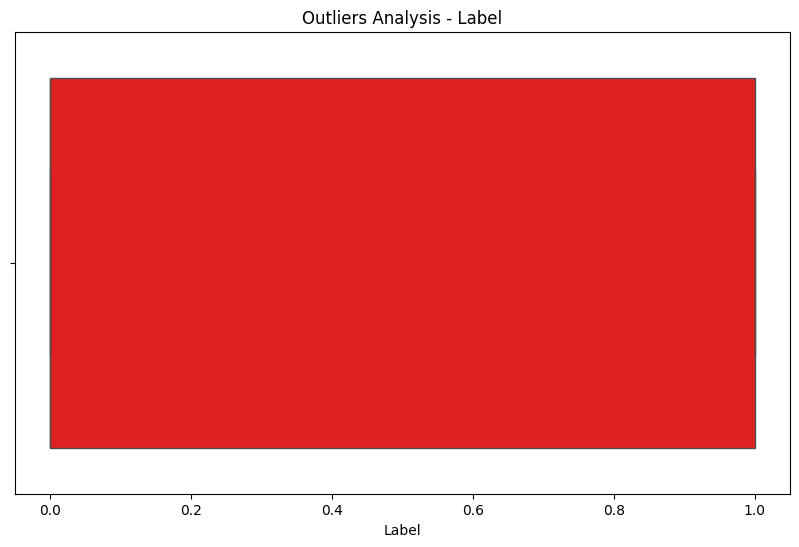

In [39]:
# ===============================
# ⚠️ Advanced Outlier Detection
# ===============================

# Using IQR method for detailed outlier analysis
for col in numerical_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[col] < (Q1 - 1.5 * IQR)) | (data[col] > (Q3 + 1.5 * IQR))]
    print(f"\n⚠️ Outliers in {col}: {len(outliers)}")

    # Boxplot for visualizing outliers
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data, x=col, color='red')
    plt.title(f'Outliers Analysis - {col}')
    plt.show()

In [45]:
# ===============================
# ⭐ Feature Importance (Statistical)
# ===============================
# # Using correlation to identify top features
top_features = correlation_matrix.abs().mean().sort_values(ascending=False).index[:5]
print("\n⭐ Top Features Based on Correlation:")
print(top_features)


⭐ Top Features Based on Correlation:
Index(['Packet_Length', 'Source_Port', 'Inbound', 'Avg_Packet_Size',
       'Flow_Packets/s'],
      dtype='object')


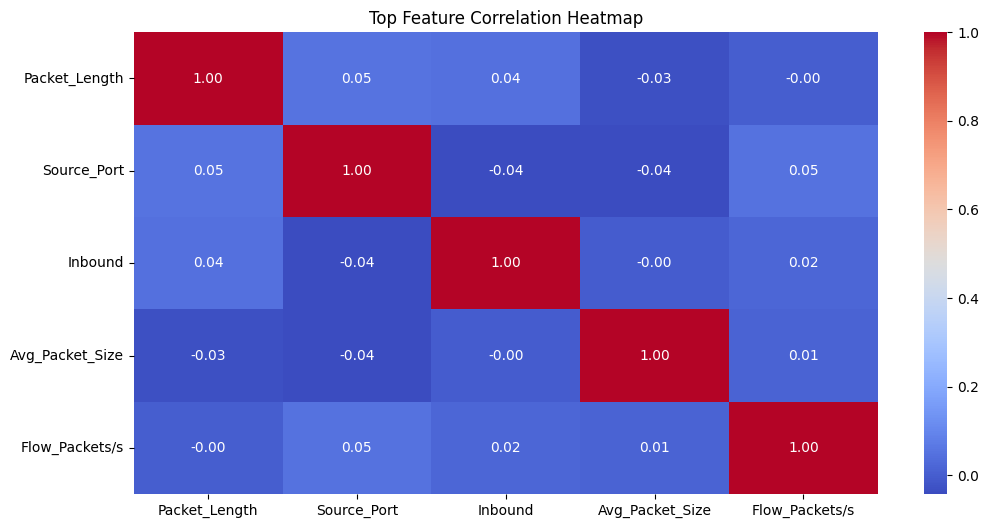

In [46]:

# Visualizing the most important features
plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix.loc[top_features, top_features], annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top Feature Correlation Heatmap')
plt.show()

In [47]:
# ===============================
# 📌 Next Step
# ===============================
# Use these insights to finalize feature selection and proceed to model training.
print("\n✅ Statistical analysis completed! Ready for feature engineering or model training.")


✅ Statistical analysis completed! Ready for feature engineering or model training.


In [49]:
# ===============================
# 🛠 Feature Creation
# ===============================

# 1️⃣ Total traffic feature
data['Total_Traffic'] = data['Bytes_Sent'] + data['Bytes_Received']
print("✅ New feature 'Total_Traffic' created.")

# 2️⃣ Packet ratio feature
data['Packet_Ratio'] = data['Total_Fwd_Packets'] / (data['Total_Bwd_Packets'] + 1)
print("✅ New feature 'Packet_Ratio' created.")

# 3️⃣ Traffic rate feature
data['Traffic_Rate'] = data['Flow_Bytes/s'] / (data['Flow_Packets/s'] + 1)
print("✅ New feature 'Traffic_Rate' created.")

# 4️⃣ Packet efficiency feature
data['Packet_Efficiency'] = data['Bytes_Sent'] / (data['Packet_Length'] + 1)
print("✅ New feature 'Packet_Efficiency' created.")

✅ New feature 'Total_Traffic' created.
✅ New feature 'Packet_Ratio' created.
✅ New feature 'Traffic_Rate' created.
✅ New feature 'Packet_Efficiency' created.


In [50]:
# ===============================
# 🔧 Feature Transformation
# ===============================

import numpy as np

# Features that usually have skewed distribution
skewed_features = ['Bytes_Sent', 'Bytes_Received', 'Total_Traffic', 'Flow_Bytes/s']

for col in skewed_features:
    data[f'{col}_log'] = np.log1p(data[col])   # log1p handles zero values
    print(f"✅ Log-transformed feature '{col}_log' created.")

✅ Log-transformed feature 'Bytes_Sent_log' created.
✅ Log-transformed feature 'Bytes_Received_log' created.
✅ Log-transformed feature 'Total_Traffic_log' created.
✅ Log-transformed feature 'Flow_Bytes/s_log' created.


In [51]:
# ===============================
# 🔗 Feature Encoding
# ===============================

from sklearn.preprocessing import LabelEncoder

# Find categorical columns
categorical_columns = data.select_dtypes(include=['object']).columns

# Encode them
for col in categorical_columns:
    encoder = LabelEncoder()
    data[col + '_encoded'] = encoder.fit_transform(data[col].astype(str))
    print(f"✅ Categorical feature '{col}' encoded.")

✅ Categorical feature 'Timestamp' encoded.
✅ Categorical feature 'Source_IP' encoded.
✅ Categorical feature 'Destination_IP' encoded.
✅ Categorical feature 'Protocol' encoded.
✅ Categorical feature 'Flags' encoded.
✅ Categorical feature 'Attack_Type' encoded.


In [53]:
# ===============================
# ⭐ Feature Selection (Fixed)
# ===============================

# Identifying features with low variance
from sklearn.feature_selection import VarianceThreshold

# Selecting numerical columns for variance thresholding
numerical_data = data.select_dtypes(include=['float64', 'int64'])

# Identifying features with low variance
low_variance_filter = VarianceThreshold(threshold=0.01)
low_variance_filter.fit(numerical_data)

# Mapping low variance features to their original dataset columns
low_variance_features = numerical_data.columns[~low_variance_filter.get_support()]
print(f"\n⚠️ Low variance features detected and removed: {list(low_variance_features)}")

# Dropping low variance features from the original dataset
data.drop(columns=low_variance_features, inplace=True, errors='ignore')


⚠️ Low variance features detected and removed: []


In [55]:

# Removing redundant features (e.g., original features replaced by transformed ones)
redundant_features = ['bytes_in', 'bytes_out', 'traffic_intensity']
data.drop(columns=redundant_features, inplace=True, errors='ignore')
print("✅ Redundant features removed.")

✅ Redundant features removed.


In [56]:
# ===============================
# 📋 Final Dataset Summary
# ===============================

print("\n📋 Final Dataset Features:")
print(data.columns)

print("\n🔢 Final Dataset Shape:", data.shape)


📋 Final Dataset Features:
Index(['Timestamp', 'Source_IP', 'Destination_IP', 'Protocol', 'Packet_Length',
       'Duration', 'Source_Port', 'Destination_Port', 'Bytes_Sent',
       'Bytes_Received', 'Flags', 'Flow_Packets/s', 'Flow_Bytes/s',
       'Avg_Packet_Size', 'Total_Fwd_Packets', 'Total_Bwd_Packets',
       'Fwd_Header_Length', 'Bwd_Header_Length', 'Sub_Flow_Fwd_Bytes',
       'Sub_Flow_Bwd_Bytes', 'Inbound', 'Attack_Type', 'Label',
       'Total_Traffic', 'Packet_Ratio', 'Traffic_Rate', 'Packet_Efficiency',
       'Bytes_Sent_log', 'Bytes_Received_log', 'Total_Traffic_log',
       'Flow_Bytes/s_log', 'Timestamp_encoded', 'Source_IP_encoded',
       'Destination_IP_encoded', 'Protocol_encoded', 'Flags_encoded',
       'Attack_Type_encoded'],
      dtype='object')

🔢 Final Dataset Shape: (1430, 37)


In [58]:

# ===============================
# 🔧 Verification
# ===============================

print("\n📋 Final Dataset After Removing Low Variance Features:")
print(data.info())


📋 Final Dataset After Removing Low Variance Features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               1430 non-null   object 
 1   Source_IP               1430 non-null   object 
 2   Destination_IP          1430 non-null   object 
 3   Protocol                1430 non-null   object 
 4   Packet_Length           1430 non-null   float64
 5   Duration                1430 non-null   float64
 6   Source_Port             1430 non-null   float64
 7   Destination_Port        1430 non-null   float64
 8   Bytes_Sent              1430 non-null   float64
 9   Bytes_Received          1430 non-null   float64
 10  Flags                   1430 non-null   object 
 11  Flow_Packets/s          1430 non-null   float64
 12  Flow_Bytes/s            1430 non-null   float64
 13  Avg_Packet_Size         1430 non-null 

In [60]:
# ===============================
# 📌 Next Step
# ===============================
# Proceed to splitting the dataset into training and testing sets for model training.
print("\n✅ Feature engineering completed! Ready for model training.")


✅ Feature engineering completed! Ready for model training.


In [61]:
# ===============================
# 📋 Step 1: Column Validation and Dataset Overview
# ===============================
print("\n📋 Available Columns in Dataset:")
print(data.columns)


📋 Available Columns in Dataset:
Index(['Timestamp', 'Source_IP', 'Destination_IP', 'Protocol', 'Packet_Length',
       'Duration', 'Source_Port', 'Destination_Port', 'Bytes_Sent',
       'Bytes_Received', 'Flags', 'Flow_Packets/s', 'Flow_Bytes/s',
       'Avg_Packet_Size', 'Total_Fwd_Packets', 'Total_Bwd_Packets',
       'Fwd_Header_Length', 'Bwd_Header_Length', 'Sub_Flow_Fwd_Bytes',
       'Sub_Flow_Bwd_Bytes', 'Inbound', 'Attack_Type', 'Label',
       'Total_Traffic', 'Packet_Ratio', 'Traffic_Rate', 'Packet_Efficiency',
       'Bytes_Sent_log', 'Bytes_Received_log', 'Total_Traffic_log',
       'Flow_Bytes/s_log', 'Timestamp_encoded', 'Source_IP_encoded',
       'Destination_IP_encoded', 'Protocol_encoded', 'Flags_encoded',
       'Attack_Type_encoded'],
      dtype='object')


In [67]:
# Identify numerical and categorical columns
numerical_features = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = data.select_dtypes(include=['object']).columns.tolist()

print(f"\n🔢 Numerical Features: {numerical_features}")
print(f"🗂️ Categorical Features: {categorical_features}")


🔢 Numerical Features: ['Packet_Length', 'Duration', 'Source_Port', 'Destination_Port', 'Bytes_Sent', 'Bytes_Received', 'Flow_Packets/s', 'Flow_Bytes/s', 'Avg_Packet_Size', 'Total_Fwd_Packets', 'Total_Bwd_Packets', 'Fwd_Header_Length', 'Bwd_Header_Length', 'Sub_Flow_Fwd_Bytes', 'Sub_Flow_Bwd_Bytes', 'Inbound', 'Label', 'Total_Traffic', 'Packet_Ratio', 'Traffic_Rate', 'Packet_Efficiency', 'Bytes_Sent_log', 'Bytes_Received_log', 'Total_Traffic_log', 'Flow_Bytes/s_log', 'Timestamp_encoded', 'Source_IP_encoded', 'Destination_IP_encoded', 'Protocol_encoded', 'Flags_encoded', 'Attack_Type_encoded']
🗂️ Categorical Features: ['Timestamp', 'Source_IP', 'Destination_IP', 'Protocol', 'Flags', 'Attack_Type']
